# Deep Learning - 2026

## Index

1. [Problem Definition](#Problem-Definition)

2. [Dependencies](#Dependencies)

3. [Auxiliary Functions / Code](#Auxiliary-functions-/code)

4. [Load Data](#Load-Data)

5. [Explore the Data](#Explore-the-Data)

6. [Transform Data](#Transform-Data)

7. [Modeling — Stage 1: Binary Classification (DS1)](#Stage-1-—-Binary-Classification-\(Dataset\))

8. [Modeling — Stage 2: Turbine Count (DS2)](#Modeling---Stage-2-\(Turbine-Count-transfer-learning-V3-model\))

9. [Modeling — Stage 3: Transfer Learning (DS2)](#Modeling---Stage-3-\(Turbine-Count-with-Transfer-Learning\))

10. [Modeling — Stage 4: Return to Binary Classification](#Modeling---Stage-4-\(Return-to-binary-classification\))

11. [Predict for the Test Set](#Predict-for-the-test-set)

12. [The Utility of the Models Created](#The-utility-of-the-model-\(s\)-created)

13. [Future Work](#Future-work)


## Problem Definition

### Context

Wind turbines generate electricity from wind. More and more states and private companies are investing in renewable energies and building wind turbine plants. Knowing the installed capacity and wind turbine locations could help in energy production forecast - in the case of wind turbines, public records are very accurate and the whole fleet is already mapped in databases, but this exercise serves a wider purpose. Deep Learning could help identify and count wind turbines on satellite image. 

A similar exercise could be done for example, on solar panels for which there's distributed micro generation which is harder to completely map from public databases.


### Objective

Considering the above, the objective should be **Turbine Counting**. For the purpose of this assignment, I wanted to make sure to start small and guaratee that I have a working model before tackling a problem that's too hard, so I is split the objectives into two stages:

1. Perform Binary Classification, detecting if images **contain** or do **not contain** wind turbines.
2. Perform **Turbine Counting** (Multi-class Classification).
    - Turbine counting would make more sense to be seen as a regression problem, but since the first stage is classification, I'll follow with classification for the purposes of this assignment in order to avoid forking the narrative.

So, the output of the models used **will not** be the number of turbines as in a regression problem, but the problem will be interpreted as a classification problem, with the model predicting in which bin the image belongs.


### Metric

Accuracy (primary). The target is **95%** for this problem. 

1. For stage 1, the class imbalance (~57/43) is moderate and consistent across splits, so accuracy is acceptable as a first metric.
2. For stage 2, the class imbalance depends on how the binning is done and the number of images per bin, so we'll go through that below.


## Dependencies

In [348]:
import os
import stat
import json
import random
import shutil
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warnings, 3=errors only
os.makedirs("saved_models", exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score, f1_score

In [349]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Auxiliary functions /code

In [350]:
def count_n_images_iterator(this_iterator, name, what='images'):
    """
    Function to count the number of items (images/batches) in the dataset that
    is an iterator. Does not return. Prints a string.

    Input:
        this_iterator: tf.data.Dataset
            Iterator containing the data. TensorFlow Dataset.
        name: str
            Name of the dataset. Should be 'train','test','validation'
        what: str
            Specifies if we are dealing with single images or batches. Should
            be 'images' or 'batches'.

    Output:
        None
    """

    count_items = 0
    for _ in this_iterator:
        count_items += 1

    print(f'The {name} dataset has {count_items} {what}.')


In [351]:
def plot_acuracy_loss(history):
    """
    Adapted from: https://www.tensorflow.org/tutorials/images/classification
    """
    h = history.history if hasattr(history, 'history') else history

    acc = h['accuracy']
    val_acc = h['val_accuracy']

    loss = h['loss']
    val_loss = h['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()


In [ ]:
IMG_SIZE = (128, 128) # images for dataset 1 are already 128x128, but we'll ensure that and also use this for dataset 2

def make_dataset(files, labels, shuffle=False):
    """
    Builds a tf.data.Dataset from file paths and labels.
    Loads each JPEG, decodes it, and resizes to IMG_SIZE (128×128).

    Inputs:
        files: array-like — paths to image files
        labels: array-like — corresponding integer labels
        shuffle: bool — if True, shuffles with buffer_size=10000, seed=42
    Output:
        tf.data.Dataset yielding (image: uint8 tensor, label) pairs
    """
    def load(path, label):
        """
        Same as make_dataset but resizes images to IMG_SIZE_224 (224×224).
        Used to build datasets for EfficientNetB0 which expects 224×224 input.

        Inputs:
            files: array-like — paths to image files
            labels: array-like — corresponding integer labels
            shuffle: bool — if True, shuffles with buffer_size=10000, seed=42
        Output:
            tf.data.Dataset yielding (image: uint8 tensor, label) pairs
        """
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(tf.image.resize(img, IMG_SIZE), tf.uint8)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
def normalize_image(image, label):
    """
    Normalises pixel values from [0, 255] to [0.0, 1.0] as float32.

    Inputs:
        image: uint8 tensor — raw image
        label: tensor — unchanged label
    Output:
        (float32 image, label) tuple
    """
    return tf.cast(image, tf.float32) / 255.0, label


In [ ]:

def make_early_stop(patience=5):
    """
    Returns a Keras EarlyStopping callback monitoring val_accuracy.

    Input:
        patience: int — number of epochs with no improvement before stopping
    Output:
        tf.keras.callbacks.EarlyStopping with restore_best_weights=True
    """
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=patience,
        restore_best_weights=True
    )


In [ ]:
def preprocess_mobilenet(img, lbl):
    """
    Applies MobileNetV2 preprocessing: casts to float32 then scales
    pixel values to [-1, 1] as required by MobileNetV2.

    Inputs:
        img: tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (preprocessed float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32)
    return mobilenet_preprocess(img), lbl

In [ ]:
def preprocess_effnet(img, lbl):
    """
    Applies EfficientNet preprocessing: casts to float32 (keeping [0, 255]
    range) then applies EfficientNet's built-in normalisation.

    Inputs:
        img: tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (preprocessed float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32)
    return effnet_preprocess(img), lbl

In [ ]:
def preprocess_and_augment(img, lbl):
    """
    Applies data augmentation (flip, rotation, zoom, brightness) then
    EfficientNet preprocessing. Used for the augmented EfficientNet pipeline.

    Inputs:
        img: tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (augmented and preprocessed float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32)
    img = augment(img, training=True)
    return preprocess_effnet(img, lbl)

In [ ]:
def load_and_resize_224(path, label):
    """
    Loads a JPEG image from disk and resizes to 224×224 as float32.
    Used inside the EfficientNetB0 targeted oversampling pipeline
    where images are built from file paths rather than a pre-built dataset.

    Inputs:
        path: string tensor — path to JPEG file
        label: tensor — unchanged label
    Output:
        (float32 image of shape (224, 224, 3), label) tuple
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    return img, label

def effnet_augment(img, lbl):
    """
    Applies augmentation via augment_layer then EfficientNet preprocessing.
    Used for rare classes in the EfficientNetB0 targeted oversampling pipeline.

    Inputs:
        img: float32 tensor — image already loaded and resized to 224×224
        lbl: tensor — unchanged label
    Output:
        (augmented and preprocessed float32 image, label) tuple
    """
    img = augment_layer(img, training=True)
    return effnet_preprocess(img), lbl

def effnet_only(img, lbl):
    """
    Applies only EfficientNet preprocessing without augmentation.
    Used for majority classes and for val/test pipelines.

    Inputs:
        img: float32 tensor — image already loaded and resized to 224×224
        lbl: tensor — unchanged label
    Output:
        (preprocessed float32 image, label) tuple
    """
    return effnet_preprocess(img), lbl

# Bucket each train label to know which class it belongs to (for oversampling)
def get_bucket_np(n):
    """
    Alias of get_bucket. Maps a raw turbine count to its bucket index.
    Used in the EfficientNetB0 targeted oversampling pipeline.

    Input:
        n: int — raw turbine count
    Output:
        int — bucket index (0–6)
    """
    if n == 0: return 0
    if n == 1: return 1
    if n == 2: return 2
    if n == 3: return 3
    if n <= 5: return 4
    if n <= 9: return 5
    return 6

In [359]:
def make_dataset_224(files, labels, shuffle=False):
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(tf.image.resize(img, IMG_SIZE_224), tf.uint8)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
def preprocess_mobilenet_aug(img, lbl):
    """
    Applies data augmentation (flip, rotation, zoom, brightness) then
    MobileNetV2 preprocessing. Used for the augmented MobileNetV2 pipeline.

    Inputs:
        img: tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (augmented and preprocessed float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32)
    img = augment(img, training=True)
    return mobilenet_preprocess(img), lbl

In [ ]:
def bucket_label(img, lbl):
    """
    Maps a raw turbine count label to one of 7 ordinal bucket indices.
    Runs inside a tf.data pipeline (uses tf.case for graph compatibility).

    Bucket mapping: 0→0, 1→1, 2→2, 3→3, 4–5→4, 6–9→5, 10+→6

    Inputs:
        img: tensor — image, passed through unchanged
        lbl: int tensor — raw turbine count
    Output:
        (image, bucket_index) tuple
    """
    lbl = tf.cast(lbl, tf.int32)
    bucket = tf.case([
        (lbl == 0, lambda: tf.constant(0)),
        (lbl == 1, lambda: tf.constant(1)),
        (lbl == 2, lambda: tf.constant(2)),
        (lbl == 3, lambda: tf.constant(3)),
        (lbl <= 5, lambda: tf.constant(4)),
        (lbl <= 9, lambda: tf.constant(5)),
    ], default=lambda: tf.constant(6))
    return img, bucket

In [ ]:
def get_bucket(count):
    """
    NumPy-side version of bucket_label. Maps a raw turbine count to its
    bucket index. Used to compute per-class masks for targeted oversampling.

    Bucket mapping: 0→0, 1→1, 2→2, 3→3, 4–5→4, 6–9→5, 10+→6

    Input:
        count: int — raw turbine count
    Output:
        int — bucket index (0–6)
    """
    if count == 0: return 0
    if count == 1: return 1
    if count == 2: return 2
    if count == 3: return 3
    if count <= 5: return 4
    if count <= 9: return 5
    return 6

In [ ]:
def normalize_and_augment(img, lbl):
    """
    Normalises pixels to [0.0, 1.0] then applies data augmentation
    (flip, rotation, zoom, brightness). Used for rare classes in the
    Stage 2 targeted oversampling pipeline.

    Inputs:
        img: uint8 tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (augmented float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32) / 255.0
    img = augment(img, training=True)
    return img, lbl

def normalize_only(img, lbl):
    """
    Same as normalize_image. Normalises pixels to [0.0, 1.0] as float32.
    Used in targeted oversampling pipelines for non-augmented classes.

    Inputs:
        img: uint8 tensor — raw image
        lbl: tensor — unchanged label
    Output:
        (float32 image, label) tuple
    """
    img = tf.cast(img, tf.float32) / 255.0
    return img, lbl

In [420]:
def make_binary_label(img, lbl):
    """
    Converts a turbine count label to a binary presence/absence label.
    Used in Stage 4 binary classification pipelines.

    Inputs:
        img: tensor — image, passed through unchanged
        lbl: int tensor — raw turbine count
    Output:
        (image, binary_label) tuple where binary_label is 1 if lbl > 0, else 0
    """
    return img, tf.cast(lbl > 0, tf.int32)


In [435]:
def evaluate_softmax(model, dataset):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    acc  = (y_pred == y_true).mean()
    qwk  = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    return acc, qwk

def evaluate_binary(model, dataset):
    y_pred_probs = model.predict(dataset, verbose=0)
    probs = tf.sigmoid(y_pred_probs).numpy().flatten()
    y_pred = (probs >= 0.5).astype(int)
    y_true = np.concatenate([y.numpy().flatten().astype(int) for _, y in dataset])
    acc = (y_pred == y_true).mean()
    return acc, None

## Load Data

### Raw Datasets

| | Dataset 1 | Dataset 2 |
|---|---|---|
| **Source** | Airbus SPOT6/SPOT7 satellite imagery | YOLOv3 overhead imagery |
| **Image size** | 128×128 px | 608×608 px (resized to 128×128) |
| **Channels** | 3 (RGB) | 3 (RGB) |
| **Total images** | 429,011 | 1,742 |
| **Classes** | background (0), target (1) | background (0), target (1) |
| **Class balance** | ~57% / 43% | ~26% / 74% |

DS1 has a moderate and consistent imbalance across splits (~57/43). 

DS2 is more imbalanced (~26/74) and much smaller — this will be more relevant for stage 2 modelling decisions.

### TensorFlow Datasets

| Split | DS1 — total | DS1 — background | DS1 — target | DS2 — total | DS2 — background | DS2 — target |
|---|---|---|---|---|---|---|
| **Train** | 143,003 | 81,073 (56.7%) | 61,930 (43.3%) | 580 | 157 (27.1%) | 423 (72.9%) |
| **Test** | 143,004 | 81,205 (56.8%) | 61,799 (43.2%) | 581 | 159 (27.4%) | 422 (72.6%) |
| **Validation** | 143,004 | 80,800 (56.5%) | 62,204 (43.5%) | 581 | 141 (24.3%) | 440 (75.7%) |




### Download from Kaggle

#### **Dataset 1**

This is very simple dataset of satellite images with or without wind turbine.

- Extracts of **128 x 128 pixels** with wind turbines are located in a folder called targets
- extracts without wind turbines are located in a folder called background. 
- Images are extracted from satellite acquisitions from the Airbus SPOT6 and SPOT7 satellites which resolution is 1.5 meters per pixel. 
- So extracts of **128 x 128 pixels** represents roughly 192 meters on the ground which is compatible with the typical size of a wind turbine.

(from Kaggle @ https://www.kaggle.com/datasets/airbusgeo/airbus-wind-turbines-patches/data)

In [364]:
# Point Kaggle API to the kaggle.json in the project root
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.cwd())

DS1_DIR = Path("data/ds1")
DS1_DIR.mkdir(exist_ok=True)

if not any(DS1_DIR.iterdir()):   # skip if already downloaded
    os.system(f"kaggle datasets download -d <username>/<dataset-name> -p {DS1_DIR} --unzip")


#### **Dataset 2**

This is a set of overhead images of wind turbines with corresponding YOLOv3 formatted labels for object detection. 

- These labels contain the **class**, **x** and **y** coordinates and the **height** and **width** of the bounding boxes for each wind turbine in the corresponding image.
- This data was then preprocessed into smaller images with dimensions of **608x608** and their corresponding labels with the same YOLOv3 format of class, x, y, height, width. 
- These values (except for class value) have relative values from 0-1 that are proportional to the size of the images. These smaller images and labels are what are contained in the dataset. 
- These images have resolutions varying from 0.6-1m.

(from Kaggle @ https://www.kaggle.com/datasets/saurabhshahane/wind-turbine-obj-detection)

In [365]:
# Point Kaggle API to the kaggle.json in the project root
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.cwd())

DS2_DIR = Path("data/ds2")
DS2_DIR.mkdir(parents=True, exist_ok=True)

if not any(DS2_DIR.iterdir()):  # skip if already downloaded
    os.system(f"kaggle datasets download -d saurabhshahane/wind-turbine-obj-detection -p {DS2_DIR} --unzip")

### Load from directory and Make Tensorflow Datasets

#### **Dataset 1**

In [366]:
# Load data from 
DS1_DIR = Path("data/ds1")
DS1_DIR.mkdir(exist_ok=True)

for root, dirs, files in os.walk(DS1_DIR):
    dirs.sort()
    level = root.replace(str(DS1_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 2:          # don't recurse too deep
        dirs.clear()

ds1/  (0 files)
  train/  (0 files)


    background/  (202565 files)
    target/  (154942 files)
  val/  (0 files)
    background/  (40513 files)
    target/  (30991 files)


##### Train, Test, Validation split
The dataset comes with a default split through different directories. It is necessary to pool from both and then split manually to create test, train and validation sets.

In [367]:
classes = ['background', 'target']  # label 0 = background, label 1 = target

# --- Step 1: Collect all image paths and their labels ---
# We pool train/ and val/ together so we can re-split on our own terms
all_files  = []   # will hold the path to each image file
all_labels = []   # will hold the class index (0 or 1) for each image

for split in ['train', 'val']:
    for label_idx, cls in enumerate(classes):
        class_dir = DS1_DIR / split / cls          # e.g. data/train/background
        for f in class_dir.iterdir():               # iterate over every file in that folder
            all_files.append(str(f))
            all_labels.append(label_idx)

# Convert lists to numpy arrays so we can index them easily later
all_files  = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Total images collected: {len(all_files)}")

# --- Step 2: Stratified split into train / test / val (~1/3 each) ---
train_files1, temp_files, train_labels1, temp_labels = train_test_split(
    all_files, all_labels, test_size=2/3, stratify=all_labels, random_state=42
)
test_files1, val_files1, test_labels1, val_labels1 = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"The train_files object has {len(train_files1)} images.")
print(f"The test_files object has {len(test_files1)} images.")
print(f"The validation_files object has {len(val_files1)} images.")


Total images collected: 429011
The train_files object has 143003 images.
The test_files object has 143004 images.
The validation_files object has 143004 images.


##### Make tensorflow datasets

In [368]:
train_dataset1 = make_dataset(train_files1, train_labels1, shuffle=True)
test_dataset1  = make_dataset(test_files1,  test_labels1)
val_dataset1   = make_dataset(val_files1,   val_labels1)

print(f"The train dataset has {len(train_files1)} images.")
print(f"The test dataset has {len(test_files1)} images.")
print(f"The validation dataset has {len(val_files1)} images.")


The train dataset has 143003 images.
The test dataset has 143004 images.
The validation dataset has 143004 images.


#### **Dataset 2**

In [369]:
DS2_DIR = Path("data/ds2")
DS2_DIR.mkdir(parents=True, exist_ok=True)

# Flatten images/images/ and labels/labels/
for folder in ['images', 'labels']:
    _nested = DS2_DIR / folder / folder
    if _nested.exists():
        dest = DS2_DIR / folder
        for f in _nested.iterdir():
            shutil.move(str(f), str(dest / f.name))
        _nested.rmdir()

# Classify into background/ and target/ based on label content
bg_dir  = DS2_DIR / "background"
tgt_dir = DS2_DIR / "target"
bg_dir.mkdir(exist_ok=True)
tgt_dir.mkdir(exist_ok=True)

for img in (DS2_DIR / "images").glob("*.jpg"):
    lbl = DS2_DIR / "labels" / (img.stem + ".txt")
    has_turbine = lbl.exists() and lbl.stat().st_size > 0
    shutil.move(str(img), str((tgt_dir if has_turbine else bg_dir) / img.name))

for root, dirs, files in os.walk(DS2_DIR):
    dirs.sort()
    level = root.replace(str(DS2_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 1:
        dirs.clear()


ds2/  (0 files)
  background/  (457 files)
  images/  (0 files)
  labels/  (1341 files)
  target/  (1285 files)


##### Train, Test, Validation split

In [370]:
classes = ['background', 'target']
LABELS_DIR = DS2_DIR / 'labels'

# --- Step 1: Collect all image paths and labels (count of turbines) ---
all_files  = []
all_labels = []
all_binary = []  # binary label for stratification (0=background, 1=target)

for label_idx, cls in enumerate(classes):
    class_dir = DS2_DIR / cls
    for f in class_dir.iterdir():
        all_files.append(str(f))
        if label_idx == 1:
            label_file = LABELS_DIR / (f.stem + '.txt')
            count = sum(1 for line in open(label_file) if line.strip()) if label_file.exists() else 0
        else:
            count = 0
        all_labels.append(count)
        all_binary.append(label_idx)

all_files  = np.array(all_files)
all_labels = np.array(all_labels)
all_binary = np.array(all_binary)

print(f"Total images collected: {len(all_files)}")

# --- Step 2: Stratified split into train / test / val (~1/3 each) ---
train_files2, temp_files, train_labels2, temp_labels, _, temp_binary = train_test_split(
    all_files, all_labels, all_binary, test_size=2/3, stratify=all_binary, random_state=42
)
test_files2, val_files2, test_labels2, val_labels2 = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_binary, random_state=42
)

print(f"The train_files object has {len(train_files2)} images.")
print(f"The test_files object has {len(test_files2)} images.")
print(f"The validation_files object has {len(val_files2)} images.")


Total images collected: 1742
The train_files object has 580 images.
The test_files object has 581 images.
The validation_files object has 581 images.


##### Make tensorflow datasets

In [371]:
train_dataset2 = make_dataset(train_files2, train_labels2, shuffle=True)
test_dataset2  = make_dataset(test_files2,  test_labels2)
val_dataset2   = make_dataset(val_files2,   val_labels2)

print(f"The train dataset has {len(train_files2)} images.")
print(f"The test dataset has {len(test_files2)} images.")
print(f"The validation dataset has {len(val_files2)} images.")

The train dataset has 580 images.
The test dataset has 581 images.
The validation dataset has 581 images.


## Explore the Data

### Dataset Overview

Both datasets are binary-labelled (background / target) and in RGB (3 channels). DS1 is large and moderately balanced; DS2 is small and imbalanced.

| | DS1 | DS2 |
|---|---|---|
| **Image size** | 128×128 px | 608×608 px |
| **Total images** | 429,011 | 1,742 |
| **Class balance** | ~57% background / ~43% target | ~26% background / ~74% target |

### Train / Test / Validation Splits

Both datasets used stratified splitting (~⅓ each). DS1 has a pre-existing split that was pooled and re-split; DS2 was split from scratch.

| Split | DS1 total | DS1 bg / target | DS2 total | DS2 bg / target |
|-------|-----------|-----------------|-----------|-----------------|
| Train | 143,003 | 56.7% / 43.3% | 580 | 26.2% / 73.8% |
| Test  | 143,004 | 56.7% / 43.3% | 581 | 26.2% / 73.8% |
| Val   | 143,004 | 56.7% / 43.3% | 581 | 26.3% / 73.7% |


### Sample Image Grids

4×4 grids of sample training images were visualised for both datasets to confirm correct loading, label assignment, and image quality.


### **Dataset 1**

In [372]:
print("Class distribution across splits:\n")
for name, files, labels in [("Train", train_files1, train_labels1),
                             ("Test",  test_files1,  test_labels1),
                             ("Val",   val_files1,   val_labels1)]:
    n_bg  = (labels == 0).sum()
    n_tgt = (labels == 1).sum()
    total = len(labels)
    print(f"{name:6} | total: {total:6} | background: {n_bg:6} ({n_bg/total:.1%}) | target: {n_tgt:6} ({n_tgt/total:.1%})")

Class distribution across splits:

Train  | total: 143003 | background:  81026 (56.7%) | target:  61977 (43.3%)
Test   | total: 143004 | background:  81026 (56.7%) | target:  61978 (43.3%)
Val    | total: 143004 | background:  81026 (56.7%) | target:  61978 (43.3%)


There's a moderate class imbalance which shouldn't be critical for the purpose of this study (~57% vs ~43%).

The imbalance is consistent across the three datasets, so corrective measure shouldn't be required - it will depend on the performance of the model.

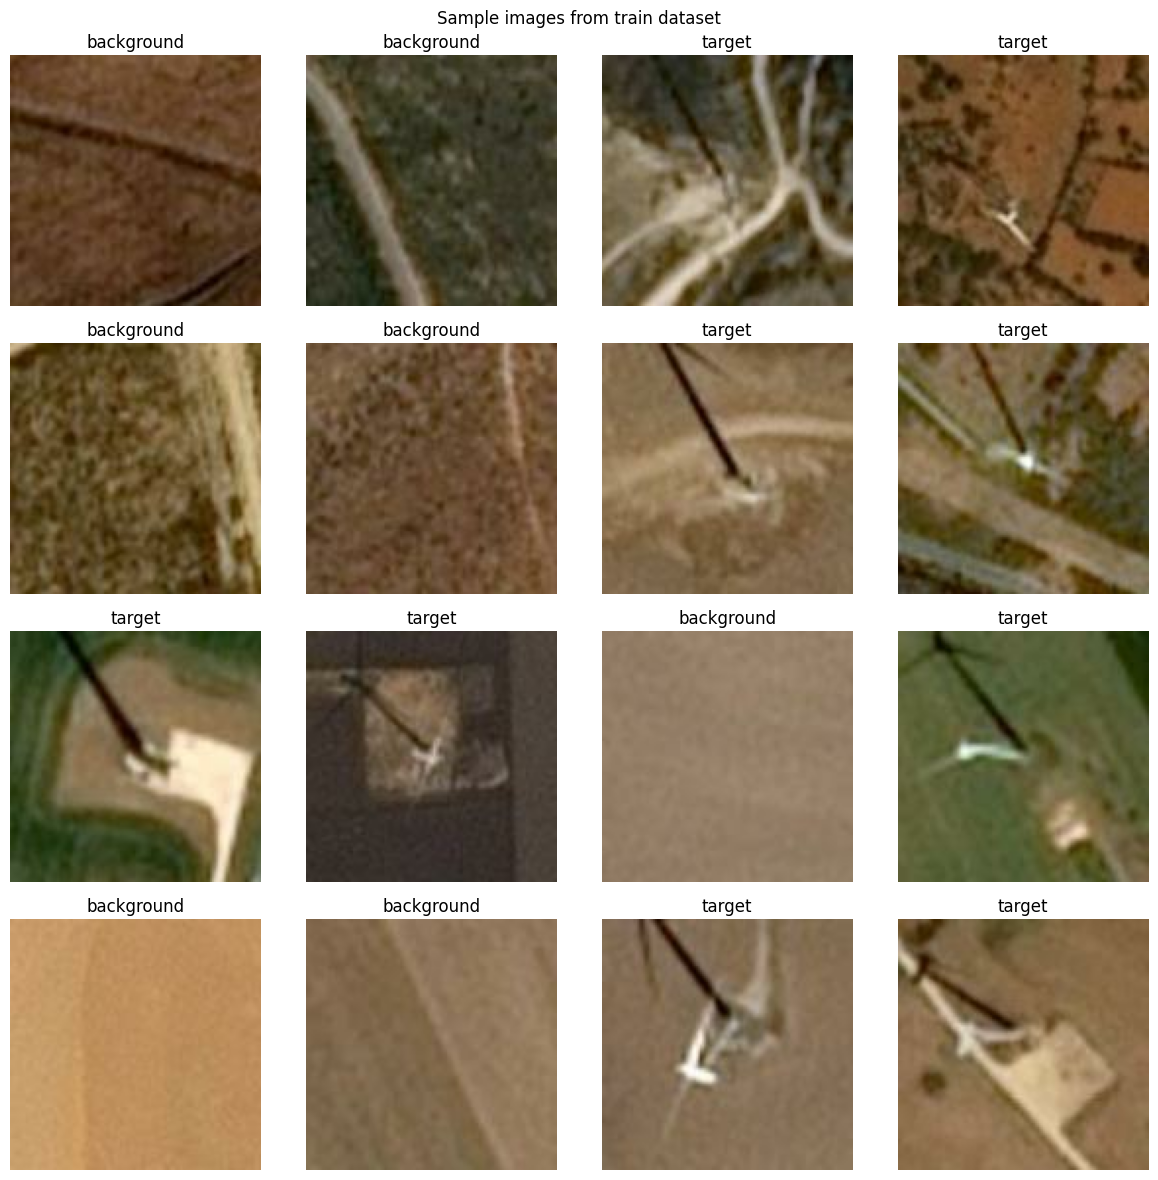

In [373]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for col, (img, label) in enumerate(train_dataset1.take(16)):
    axes[col].imshow(img.numpy())
    title = "target" if label.numpy() == 1 else "background"
    axes[col].set_title(title)
    axes[col].axis('off')

plt.suptitle("Sample images from train dataset")
plt.tight_layout()
plt.show()

The dataset contains images 128x128. This was also ensured when making the tensorflow dataset objects. There's no need to for further treatment such as cropping or padding.

The dataset has color, therefore 3 channels.

The dataset is relatively big, for the porpuse of rapid iteration a sub set of it is going to be selected.

### **Dataset 2**

In [374]:
print("Class distribution across splits:\n")
for name, files, labels in [("Train", train_files2, train_labels2),
                             ("Test",  test_files2,  test_labels2),
                             ("Val",   val_files2,   val_labels2)]:
    n_bg  = (labels == 0).sum()
    n_tgt = (labels > 0).sum()
    total = len(labels)
    print(f"{name:6} | total: {total:6} | background: {n_bg:6} ({n_bg/total:.1%}) | target: {n_tgt:6} ({n_tgt/total:.1%})")

Class distribution across splits:

Train  | total:    580 | background:    152 (26.2%) | target:    428 (73.8%)
Test   | total:    581 | background:    152 (26.2%) | target:    429 (73.8%)
Val    | total:    581 | background:    153 (26.3%) | target:    428 (73.7%)


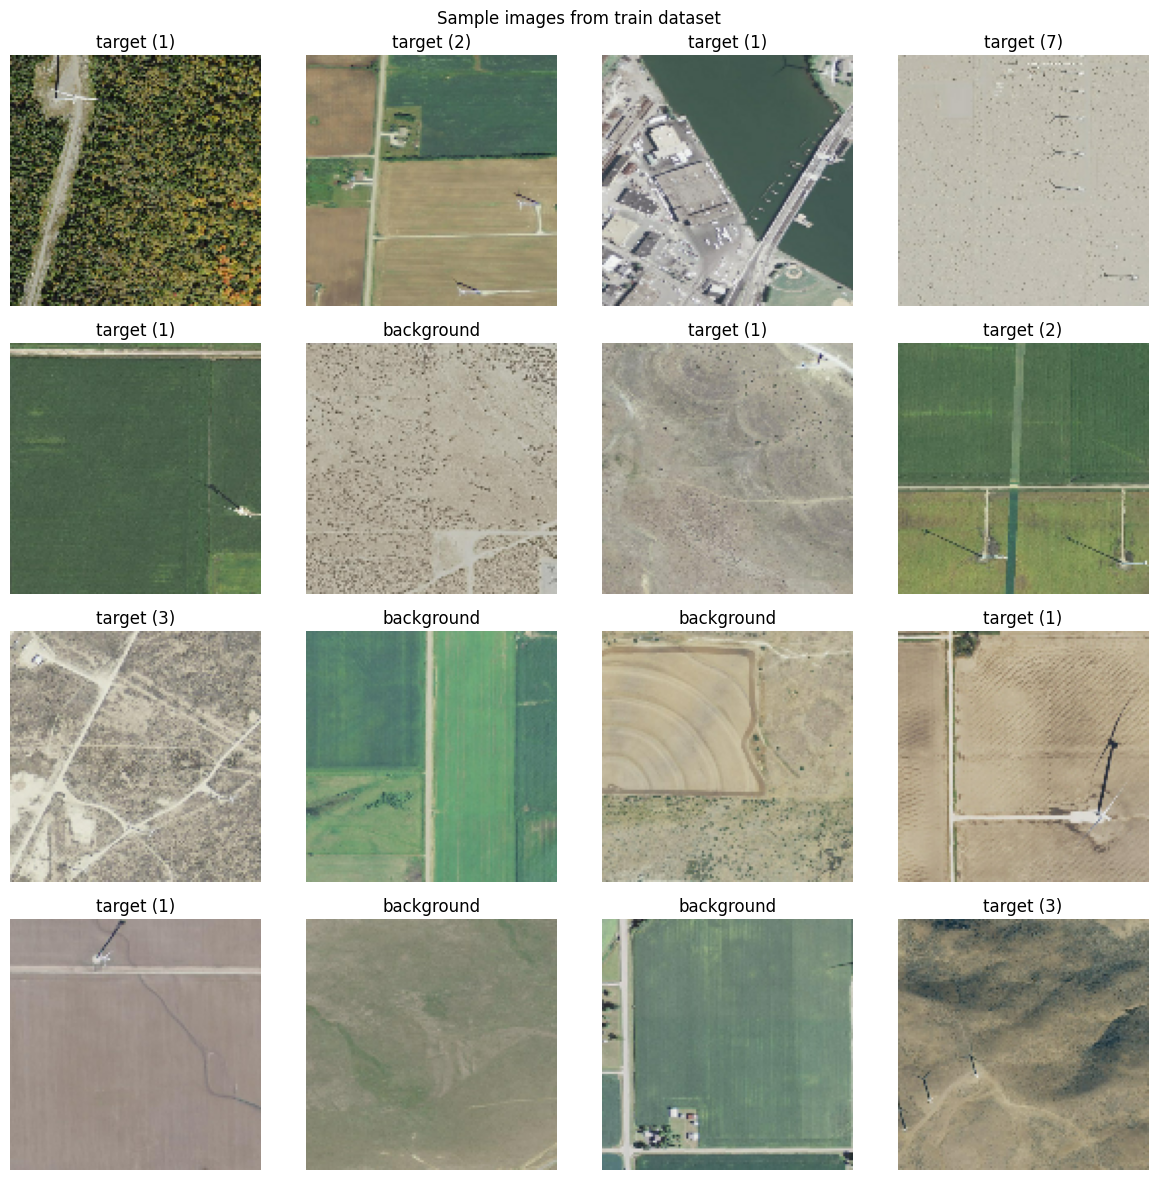

In [375]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for col, (img, label) in enumerate(train_dataset2.take(16)):
    axes[col].imshow(img.numpy())
    title = f"target ({label.numpy()})" if label.numpy() > 0 else "background"
    axes[col].set_title(title)
    axes[col].axis('off')

plt.suptitle("Sample images from train dataset")
plt.tight_layout()
plt.show()

The dataset contains images of 608×608 pixels, preprocessed from satellite acquisitions (0.6–1m resolution). Images will have to be resized to 128×128 or 224×224 depending on the models used, when building the TensorFlow dataset objects — no further padding or cropping was needed since all images share the same original dimensions.

The dataset has color, therefore 3 channels.

The dataset is significantly smaller than DS1 and more class-imbalanced (~26% target / ~74% background). Additionally, unlike DS1's binary classification labels, DS2 has turbine count labels derived from the original labels (counting the number of boxes), enabling bucketed softmax in addition to binary classification.

## Transform Data

This section prepares Dataset 1 for modelling. Dataset 2 pipelines are constructed inline at each modelling stage further below.

### Dataset 1

| Step | Detail |
|---|---|
| **Subsample** | 5,000 train / 200 test / 500 val images taken from the full dataset |
| **Normalise** | Pixel intensities scaled from `[0, 255]` to `[0.0, 1.0]` |
| **Resize** | No resizing needed — images are already 128×128 |
| **Batch & prefetch** | Batch size 32; `tf.data.AUTOTUNE` prefetch for performance → 157 train / 7 test / 16 val batches |


### **Dataset 1**

#### Create sub-sample

In [376]:
sub_ds_train1 = train_dataset1.take(5000)
sub_ds_test1  = test_dataset1.take(200)
sub_ds_val1   = val_dataset1.take(500)

count_n_images_iterator(sub_ds_train1, 'train'),
count_n_images_iterator(sub_ds_test1, 'test'),
count_n_images_iterator(sub_ds_val1, 'validation')

The train dataset has 5000 images.
The test dataset has 200 images.
The validation dataset has 500 images.


#### Normalize

Here we are normalizing the intensity of each pixel.

In [377]:
normalize_ds_train1 = sub_ds_train1.map(normalize_image)
normalize_ds_test1  = sub_ds_test1.map(normalize_image)
normalize_ds_val1   = sub_ds_val1.map(normalize_image)


#### Resize
No resizing needed since the images are already 128x128

#### Batching

In [378]:
BATCH_SIZE = 32

normalized_ds_train1 = normalize_ds_train1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
normalized_ds_test1  = normalize_ds_test1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
normalized_ds_val1   = normalize_ds_val1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

count_n_images_iterator(normalized_ds_train1, 'train', 'batches')
count_n_images_iterator(normalized_ds_test1,  'test',  'batches')
count_n_images_iterator(normalized_ds_val1,   'validation', 'batches')



The train dataset has 157 batches.
The test dataset has 7 batches.
The validation dataset has 16 batches.


# Modeling 

## Stage 1 — Binary Classification (Dataset)

Binary classification of satellite image patches: **background (0)** vs **turbine present (1)**.  
Metric: accuracy (class imbalance ~57/43 is moderate enough).  
Loss: Binary Cross-Entropy (from logits). Optimizer: Adam.

### Model Progression

| | **Architecture** | **Total params** | **Epochs** | **Best val accuracy** | **Behaviour** |
|---|---|---|---|---|---|
| **Baseline** | Conv(32) → Pool → Flatten → Dense(64) → Dense(1) | 8.1M | 20 | ~95% | Good baseline, minor overfitting |
| **v2** | 4× Conv blocks (32→64→128→256) → Dense(256) → Dense(128) → Dense(1) | 4.6M | 20 | ~98.4% | overfit achieved — train climbs to ~99.5%, val plateaus and oscillates ~96% |
| **v3** | Same as v2 + L2 regularization (1e-4) on all Conv layers + Dropout(0.5) + Dropout(0.3) | 4.6M | 20 | ~98.6% | Train ~99.2% vs val ~98.6% — small gap (~0.6%), regularization + dropout controlled overfitting |


Two things were added to v3 compared to v2:
L2 regularization (1e-4) on every Conv layer.

Dropout:
Dropout(0.5) after the first Dense layer
Dropout(0.3) after the second Dense layer

### Results & Observations

CNN progression
 — baseline → overfit → regularization+dropout. 

 The baseline model was already very good for this dataset (~95%). Increasing the complexity helped achieve overfit even though the model performed very well regardless of that. By using regularization and dropout the overfit was reduced and accuracy increased slightly and loss reduced. 
 
With a train/val gap of only ~0.6% at v3, further tuning improves very little. Training for longer should improve a bit as well.

The accuracy is so high after such little tuning and traning, that it becomes challenging to fully explore potential challenges that should have arised to enrich this assignment. For that reason, we move to Stage 2 after the third interation where overfit is improved.

### Baseline

In [379]:
model_stg1_baseline = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'), # 32 filters, 3x3 kernel, ReLU activation
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # 64 units, ReLU activation
    layers.Dense(1)
])

model_stg1_baseline.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_stg1_baseline.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,537 (31.01 MB)

 Trainable params: 8,129,537 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

In [380]:
# confirm that GPU is available and being used - in initial runs I had some issues with TensorFlow not using the GPU
# so this is a sanity check (only worked on Linux, not on Windows for some reason)
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [381]:
MODEL_STG1_BASELINE_PATH = "saved_models/model_stg1_baseline.keras"
HISTORY_STG1_BASELINE_PATH = "saved_models/model_stg1_baseline_history.json"

if os.path.exists(MODEL_STG1_BASELINE_PATH) and os.path.exists(HISTORY_STG1_BASELINE_PATH):
    print("Loading saved model_stg1_baseline...")
    model_stg1_baseline = tf.keras.models.load_model(MODEL_STG1_BASELINE_PATH)
    with open(HISTORY_STG1_BASELINE_PATH) as f:
        history_baseline = json.load(f)
else:
    epochs = 20
    hist = model_stg1_baseline.fit(
        resized_ds_train1,
        validation_data=resized_ds_val1,
        epochs=epochs
    )
    history_baseline = hist.history
    model_stg1_baseline.save(MODEL_STG1_BASELINE_PATH)
    with open(HISTORY_STG1_BASELINE_PATH, 'w') as f:
        json.dump(history_baseline, f)
    print(f"Model saved to {MODEL_STG1_BASELINE_PATH}")


Loading saved model_stg1_baseline...


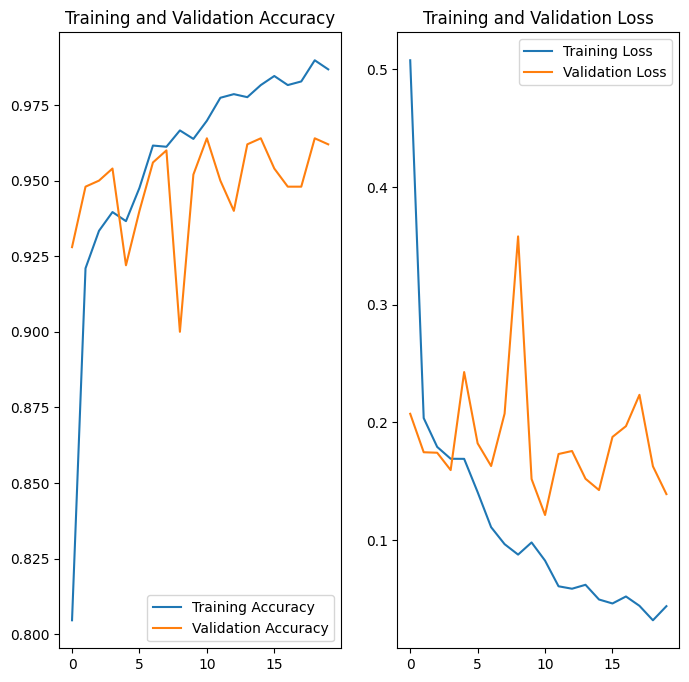

In [382]:
plot_acuracy_loss(history_baseline)

Baseline: 1 Conv(32) → Pool → Flatten → Dense(64) → Dense(1) — already ~95% val accuracy

### Increasing complexity (Trying to go for Overfitting)

In [383]:
model_stg1_v2 = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1)
])

model_stg1_v2.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_stg1_v2.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,616,001 (17.61 MB)

 Trainable params: 4,616,001 (17.61 MB)

 Non-trainable params: 0 (0.00 B)

Loading saved model_stg1_v2...


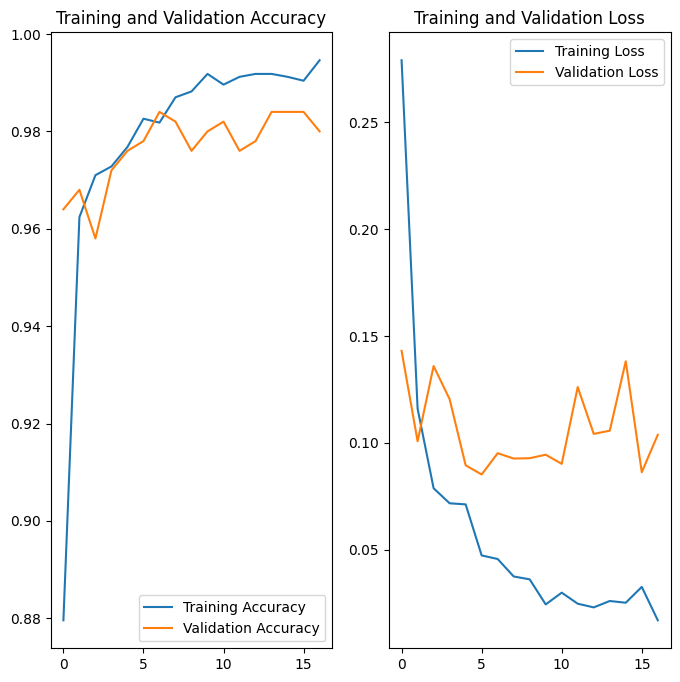

In [384]:
MODEL_STG1_V2_PATH = "saved_models/model_stg1_v2.keras"
HISTORY_STG1_V2_PATH = "saved_models/model_stg1_v2_history.json"

if os.path.exists(MODEL_STG1_V2_PATH) and os.path.exists(HISTORY_STG1_V2_PATH):
    print("Loading saved model_stg1_v2...")
    model_stg1_v2 = tf.keras.models.load_model(MODEL_STG1_V2_PATH)
    with open(HISTORY_STG1_V2_PATH) as f:
        history_stg1_v2 = json.load(f)
else:
    epochs = 20
    hist = model_stg1_v2.fit(
        resized_ds_train1,
        validation_data=resized_ds_val1,
        epochs=epochs,
        callbacks=[make_early_stop(patience=10)]
    )
    history_stg1_v2 = hist.history
    model_stg1_v2.save(MODEL_STG1_V2_PATH)
    with open(HISTORY_STG1_V2_PATH, 'w') as f:
        json.dump(history_stg1_v2, f)
    print(f"Model saved to {MODEL_STG1_V2_PATH}")

plot_acuracy_loss(history_stg1_v2)


The v2 curves confirm overfitting: validation accuracy stalls ~96% and oscillates while training keeps climbing. Adding more parameters didn't improve the model, in fact it became better at memorizing the dataset and worse at generalizing.

### Fixing Overfitting

Let's implement v3 by adding L2 regularization on all Conv layers and Dropout

In [385]:
model_stg1_v3 = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1)
])

model_stg1_v3.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_stg1_v3.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,616,001 (17.61 MB)

 Trainable params: 4,616,001 (17.61 MB)

 Non-trainable params: 0 (0.00 B)

Loading saved model_stg1_v3...


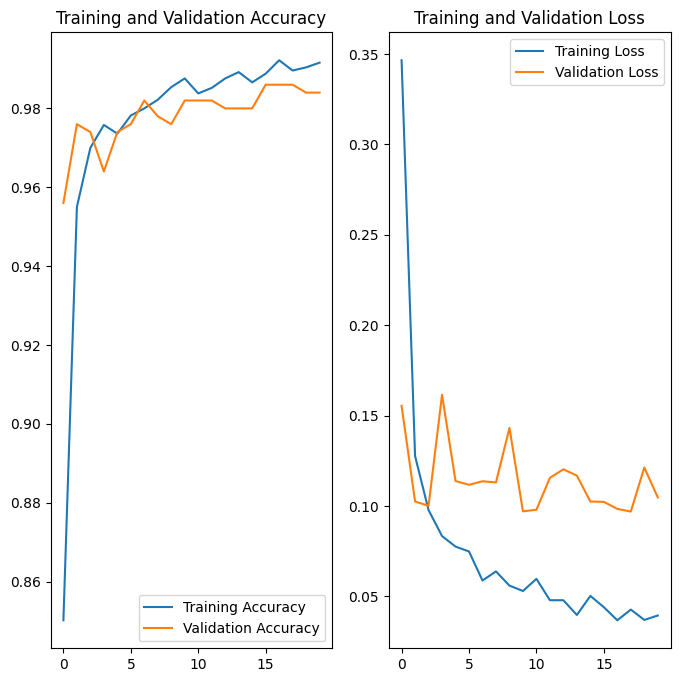

In [386]:
MODEL_STG1_V3_PATH = "saved_models/model_stg1_v3.keras"
HISTORY_STG1_V3_PATH = "saved_models/model_stg1_v3_history.json"

if os.path.exists(MODEL_STG1_V3_PATH) and os.path.exists(HISTORY_STG1_V3_PATH):
    print("Loading saved model_stg1_v3...")
    model_stg1_v3 = tf.keras.models.load_model(MODEL_STG1_V3_PATH)
    with open(HISTORY_STG1_V3_PATH) as f:
        history_stg1_v3 = json.load(f)
else:
    epochs = 20
    hist = model_stg1_v3.fit(
        resized_ds_train1,
        validation_data=resized_ds_val1,
        epochs=epochs,
        callbacks=[make_early_stop(patience=10)])

    history_stg1_v3 = hist.history

    model_stg1_v3.save(MODEL_STG1_V3_PATH)

    with open(HISTORY_STG1_V3_PATH, 'w') as f:
        json.dump(history_stg1_v3, f)
    print(f"Model saved to {MODEL_STG1_V3_PATH}")

plot_acuracy_loss(history_stg1_v3)

The model quickly reached the target accuracy, and with further tuning and training it seems that we could reach an accuracy very close to 100%. Instead of focusing on this, let's try counting.

## Modeling - Stage 2 (Turbine Count transfer learning V3 model)

As stated in the objectives, in this counting the turbines is closer to a regression problem but here I will do classification, predicting the number of turbines in each image and moving it to the right category (bucketed approach). 
The issue with classification in this sort of problem, is that predicting 1 when truth is 5 is penalized the same as predicting 4 when truth is 5. 
Another issue is that the model needs enough training examples per class which should be a challenge with this dataset - which is good for the purposed of this assignment, to see if and how we can handle it.

The label distribution in DS2 is heavily right-skewed (1–3 turbines covers ~86% of images, with a long tail up to 55). For simplification, counts are therefore bucketed into 7 ordinal classes:

| Bucket | Counts | ~Images |
|---|---|---|
| 0 | 0 | 512 |
| 1 | 1 | 693 |
| 2 | 2 | 318 |
| 3 | 3 | 123 |
| 4 | 4–5 | ~51 |
| 5 | 6–9 | ~34 |
| 6 | 10+ | ~30 |

### Approach

The convolutional layers from `model_stg1_v3` are reused as a **frozen feature extractor**, with a new softmax head trained from scratch on DS2 count labels.

| | `model_stg2_softmax` |
|---|---|
| **Backbone** | Frozen conv layers from `model_stg1_v3` |
| **Head** | Dense (7, softmax) |
| **Loss** | Categorical cross-entropy |
| **Overall accuracy** | 47% |

### Results & Observations

The model achieves **47% overall accuracy** — meaningfully above the naive baseline of always predicting bucket 1 (~40%). This shows the DS1 backbone does carry some useful spatial signal, even if it was trained on a different task.

Per-class performance degrades for higher buckets, which is expected given how sparse those classes are (~30–50 samples each). The model concentrates most predictions in buckets 0–1, where the training signal is strongest.

**Root cause of the high-count failures:** the DS1 backbone was trained to detect whether a single turbine is present in the centre of a patch — not to count turbines distributed across a scene. Its features are useful for low counts but carry little counting signal for denser images.

Despite its limitations, this is an instructive result: it establishes a baseline and motivates the move to a purpose-built pre-trained backbone (EfficientNetB0) in Stage 3, which was trained on diverse visual scenes and should extract richer spatial features for counting.



#### Count distribution in DS2

Total label files: 1340

Count distribution (all DS2 label files):

   0 turbines:   55 images  ███████████████████████████████████████████████████████
   1 turbines:  693 images  ████████████████████████████████████████████████████████████
   2 turbines:  318 images  ████████████████████████████████████████████████████████████
   3 turbines:  123 images  ████████████████████████████████████████████████████████████
   4 turbines:   33 images  █████████████████████████████████
   5 turbines:   18 images  ██████████████████
   6 turbines:    7 images  ███████
   7 turbines:   10 images  ██████████
   8 turbines:    5 images  █████
   9 turbines:   12 images  ████████████
  10 turbines:    2 images  ██
  12 turbines:    3 images  ███
  13 turbines:    4 images  ████
  14 turbines:    2 images  ██
  15 turbines:    5 images  █████
  16 turbines:    1 images  █
  17 turbines:    2 images  ██
  18 turbines:    3 images  ███
  19 turbines:    2 images  ██
  20 turbines:    2 images  ██
  21 t

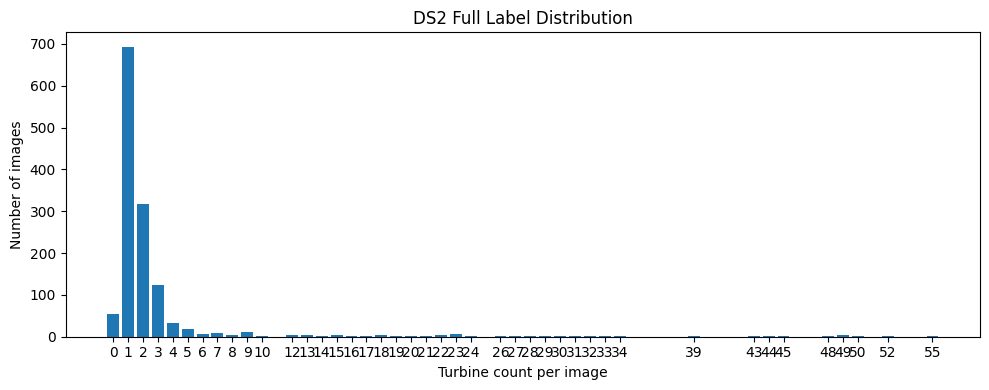

In [387]:
LABELS_DIR = Path("data/ds2/labels")

all_counts = []
for lbl_file in LABELS_DIR.glob("*.txt"):
    count = sum(1 for line in open(lbl_file) if line.strip())
    all_counts.append(count)

all_counts = np.array(all_counts)
unique, counts = np.unique(all_counts, return_counts=True)

print(f"Total label files: {len(all_counts)}\n")
print("Count distribution (all DS2 label files):\n")
for u, c in zip(unique, counts):
    bar = '█' * min(c, 60)
    print(f"  {u:2d} turbines: {c:4d} images  {bar}")

plt.figure(figsize=(10, 4))
plt.bar(unique, counts)
plt.xlabel("Turbine count per image")
plt.ylabel("Number of images")
plt.title("DS2 Full Label Distribution")
plt.xticks(unique)
plt.tight_layout()
plt.show()


#### DS2 Turbine Count Distribution

| Count range | ~Images | Notes |
|-------------|---------|-------|
| 0 | 457 | Background images |
| 1 | 693 | Most common count |
| 2 | 318 | |
| 3 | 123 | |
| 4–5 | 51 | Moderate counts |
| 6–9 | 34 | Sparse |
| 10+ | 66 | Sparse tail, counts up to 55 |


In [388]:
# ─── DS2 Pipeline for Softmax (bucketed counts) ───────────────────────────────
# Buckets: 0→0, 1→1, 2→2, 3→3, 4-5→4, 6-9→5, 10+→6
NUM_CLASSES = 7

sft_ds_train2 = (
    train_dataset2
    .map(normalize_image)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
sft_ds_val2 = (
    val_dataset2
    .map(normalize_image)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
sft_ds_test2 = (
    test_dataset2
    .map(normalize_image)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [389]:
# ─── Bucket distribution summary ──────────────────────────────────────────────
bucket_ranges = ['0', '1', '2', '3', '4–5', '6–9', '10+']
bucket_thresholds = [0, 1, 2, 3, 5, 9]



all_labels2 = np.concatenate([train_labels2, test_labels2, val_labels2])
bucketed = [get_bucket(c) for c in all_labels2]
bucket_counts = [bucketed.count(i) for i in range(7)]

print(f"{'Bucket':<8} {'Counts':<10} {'~Images':<10}")
print("-" * 30)
for i, (label, n) in enumerate(zip(bucket_ranges, bucket_counts)):
    print(f"{i:<8} {label:<10} {n:<10}")


Bucket   Counts     ~Images   
------------------------------
0        0          457       
1        1          693       
2        2          318       
3        3          123       
4        4–5        51        
5        6–9        34        
6        10+        66        


The last two buckets are thin (~34 and ~30 samples), so the model is expected to struggle.

#### Model

In [390]:
# ─── model_stg2_softmax ───────────────────────────────────────────────────────

base = tf.keras.models.load_model("saved_models/model_stg1_v3.keras")

inp = tf.keras.Input(shape=(128, 128, 3))
x = inp
for layer in base.layers:
    x = layer(x)
    layer.trainable = False
    if layer.name == "flatten_2":
        break

x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

model_stg2_softmax = tf.keras.Model(inp, outputs, name="model_stg2_softmax")

model_stg2_softmax.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_stg2_softmax.summary()


Model: "model_stg2_softmax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_48 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,486,599 (9.49 MB)

 Trainable params: 2,098,183 (8.00 MB)

 Non-trainable params: 388,416 (1.48 MB)

#### Training

In [391]:
MODEL_STG2_SFT_PATH = "saved_models/model_stg2_softmax.keras"
HISTORY_STG2_SFT_PATH = "saved_models/model_stg2_softmax_history.json"

if os.path.exists(MODEL_STG2_SFT_PATH) and os.path.exists(HISTORY_STG2_SFT_PATH):
    print("Loading saved model_stg2_softmax...")
    model_stg2_softmax = tf.keras.models.load_model(MODEL_STG2_SFT_PATH)
    with open(HISTORY_STG2_SFT_PATH) as f:
        history_stg2_sft = json.load(f)
else:
    epochs = 30
    hist = model_stg2_softmax.fit(
        sft_ds_train2,
        validation_data=sft_ds_val2,
        epochs=epochs
    )
    history_stg2_sft = hist.history
    model_stg2_softmax.save(MODEL_STG2_SFT_PATH)
    with open(HISTORY_STG2_SFT_PATH, "w") as f:
        json.dump(history_stg2_sft, f)
    print(f"Model saved to {MODEL_STG2_SFT_PATH}")


Loading saved model_stg2_softmax...


#### Performance

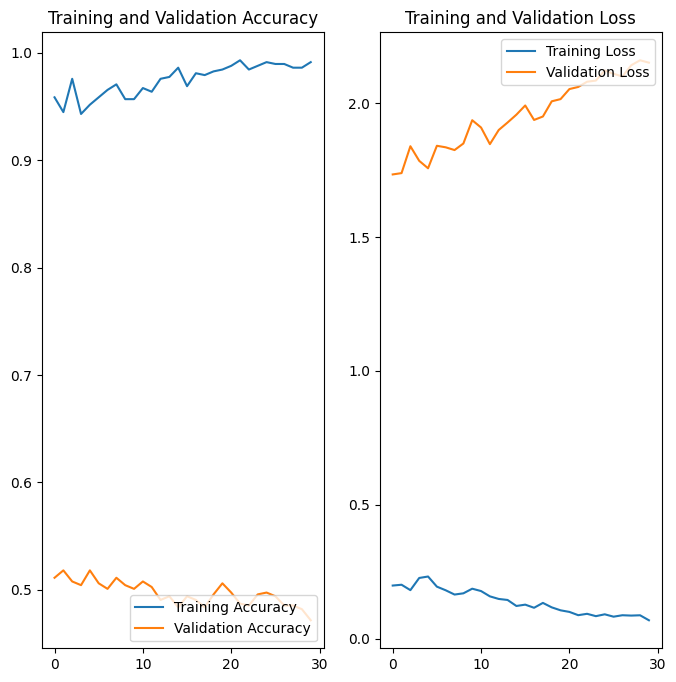

In [392]:
plot_acuracy_loss(history_stg2_sft)

We can see there's overfitting since the traning accuracy is tending towards 1, but the validation accuracy keeps decreasing and loss increasing.

The backbone is frozen, so we are only traning the last dense layer and the output layer, but because the dataset is so small, the model is still able to memorize it.

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step
Overall accuracy: 0.4716

Per-class accuracy:
      0: 58.82%  (153 samples)
      1: 60.43%  (235 samples)
      2: 29.20%  (113 samples)
      3: 9.09%  (33 samples)
    4-5: 14.29%  (14 samples)
    6-9: 20.00%  (10 samples)
    10+: 8.70%  (23 samples)


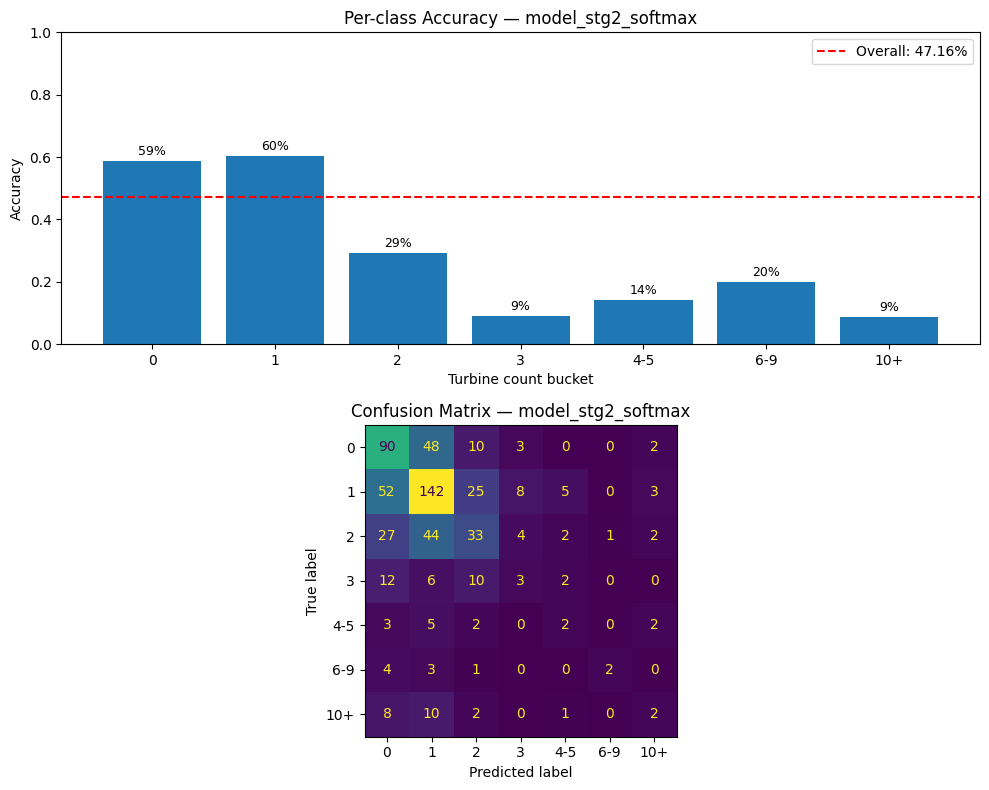

In [393]:
BUCKET_LABELS = ['0', '1', '2', '3', '4-5', '6-9', '10+']

# ─── Get predictions ──────────────────────────────────────────────────────────
y_pred_probs = model_stg2_softmax.predict(sft_ds_val2)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y.numpy() for _, y in sft_ds_val2])

# ─── Overall accuracy ─────────────────────────────────────────────────────────
overall_acc = (y_pred == y_true).mean()
print(f"Overall accuracy: {overall_acc:.4f}\n")

# ─── Per-class accuracy ───────────────────────────────────────────────────────
print("Per-class accuracy:")
for i, name in enumerate(BUCKET_LABELS):
    mask = y_true == i
    if mask.sum() == 0:
        print(f"  {name:>5}: no samples")
        continue
    acc = (y_pred[mask] == i).mean()
    n = mask.sum()
    print(f"  {name:>5}: {acc:.2%}  ({n} samples)")

# ─── Plot 1: per-class accuracy bar chart ─────────────────────────────────────
class_accs = []
for i in range(NUM_CLASSES):
    mask = y_true == i
    acc = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0
    class_accs.append(acc)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
bars = plt.bar(BUCKET_LABELS, class_accs)
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall: {overall_acc:.2%}')
plt.xlabel("Turbine count bucket")
plt.ylabel("Accuracy")
plt.title("Per-class Accuracy — model_stg2_softmax")
plt.ylim(0, 1)
plt.legend()
for bar, acc in zip(bars, class_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.0%}', ha='center', va='bottom', fontsize=9)

# ─── Plot 2: confusion matrix ──────────────────────────────────────────────────
plt.subplot(2, 1, 2)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=BUCKET_LABELS)
disp.plot(ax=plt.gca(), colorbar=False)
plt.title("Confusion Matrix — model_stg2_softmax")

plt.tight_layout()
plt.show()



The modelling is labelling a lot of the images with higher number of turbines as having zero or 1 turbine (the most common classes), behaving close to a dummy classifier that would bet on these two classes most of the time randomly. Clearly an issue stemming from very small and imbalanced sample. 

#### Investigation

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


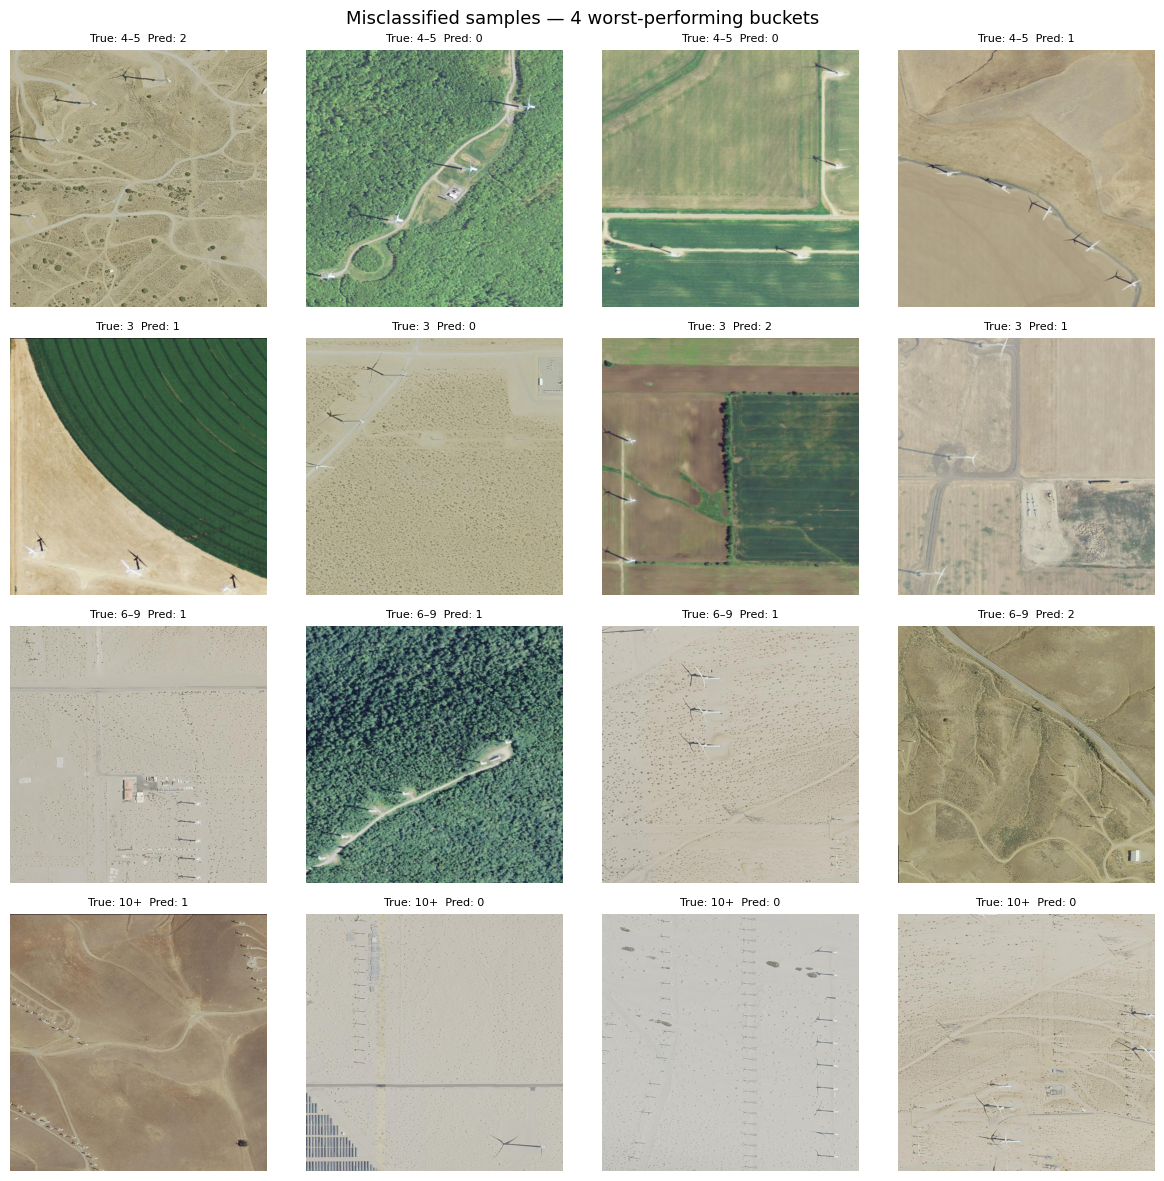

In [394]:
# ─── Failure analysis: 4 worst-performing classes ─────────────────────────────
# Get predictions on test set
y_pred = np.argmax(model_stg2_softmax.predict(sft_ds_test2), axis=1)
y_true = np.array([get_bucket(c) for c in test_labels2])

# Per-class accuracy
class_acc = []
for i in range(NUM_CLASSES):
    mask = y_true == i
    acc = (y_pred[mask] == i).mean() if mask.sum() > 0 else 1.0
    class_acc.append((acc, i))

# 4 worst classes by accuracy
worst_classes = [i for _, i in sorted(class_acc)[:4]]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
bucket_ranges = ['0', '1', '2', '3', '4–5', '6–9', '10+']

for row, cls in enumerate(worst_classes):
    # Find misclassified images in this class
    mask = (y_true == cls) & (y_pred != cls)
    wrong_indices = np.where(mask)[0]
    sample_indices = wrong_indices[:4] if len(wrong_indices) >= 4 else wrong_indices

    for col in range(4):
        ax = axes[row, col]
        if col < len(sample_indices):
            idx = sample_indices[col]
            img = mpimg.imread(test_files2[idx])
            ax.imshow(img)
            ax.set_title(
                f"True: {bucket_ranges[y_true[idx]]}  Pred: {bucket_ranges[y_pred[idx]]}",
                fontsize=8
            )
        else:
            ax.axis('off')
        ax.axis('off')

    axes[row, 0].set_ylabel(
        f"Bucket {cls} ({bucket_ranges[cls]})\nacc={class_acc[cls][0]:.0%}",
        fontsize=9, rotation=0, labelpad=60, va='center'
    )

plt.suptitle("Misclassified samples — 4 worst-performing buckets", fontsize=13)
plt.tight_layout()
plt.show()


Sometimes the model struggles to distinguish from the background when turbines are places along shapes (like roads). Other times the model is failing to predit the correct number because there are turbines of different sizes or some of the turbines are placed near the edges. I won't deep dive at this point, as 47% is not a lot of accuracy (barelly better than dummy) and we can try to improve before fine-tuning.

#### Retraining with class weights

Let's try to improve performance by adding class weights - penalizing the model for getting the non-dominant classes wrong.

In [395]:
bucketed_train = np.array([get_bucket(c) for c in train_labels2])

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=bucketed_train
)
class_weight_dict = dict(enumerate(weights))

print(f"{'Bucket':<8} {'Counts':<10} {'Weight':<10}")
print("-" * 30)
for i, (label, n, w) in enumerate(zip(bucket_ranges, bucket_counts, weights)):
    print(f"{i:<8} {label:<10} {w:<10.3f}")



Bucket   Counts     Weight    
------------------------------
0        0          0.545     
1        1          0.368     
2        2          0.804     
3        3          2.071     
4        4–5        3.602     
5        6–9        7.532     
6        10+        3.187     


In [396]:
MODEL_STG2_SFT_CW_PATH = "saved_models/model_stg2_softmax_cw.keras"
HISTORY_STG2_SFT_CW_PATH = "saved_models/model_stg2_softmax_cw_history.json"

if os.path.exists(MODEL_STG2_SFT_CW_PATH) and os.path.exists(HISTORY_STG2_SFT_CW_PATH):
    print("Loading saved model_stg2_softmax_cw...")
    model_stg2_softmax_cw = tf.keras.models.load_model(MODEL_STG2_SFT_CW_PATH)
    with open(HISTORY_STG2_SFT_CW_PATH) as f:
        history_stg2_sft_cw = json.load(f)
else:
    base = tf.keras.models.load_model("saved_models/model_stg1_v3.keras")
    inp = tf.keras.Input(shape=(128, 128, 3))
    x = inp
    for layer in base.layers:
        x = layer(x)
        layer.trainable = False
        if layer.name == "flatten_2":
            break

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

    model_stg2_softmax_cw = tf.keras.Model(inp, outputs, name="model_stg2_softmax_cw")
    model_stg2_softmax_cw.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    epochs = 30
    hist = model_stg2_softmax_cw.fit(
        sft_ds_train2,
        validation_data=sft_ds_val2,
        epochs=epochs,
        class_weight=class_weight_dict
    )
    history_stg2_sft_cw = hist.history
    model_stg2_softmax_cw.save(MODEL_STG2_SFT_CW_PATH)
    with open(HISTORY_STG2_SFT_CW_PATH, "w") as f:
        json.dump(history_stg2_sft_cw, f)
    print(f"Model saved to {MODEL_STG2_SFT_CW_PATH}")


Loading saved model_stg2_softmax_cw...


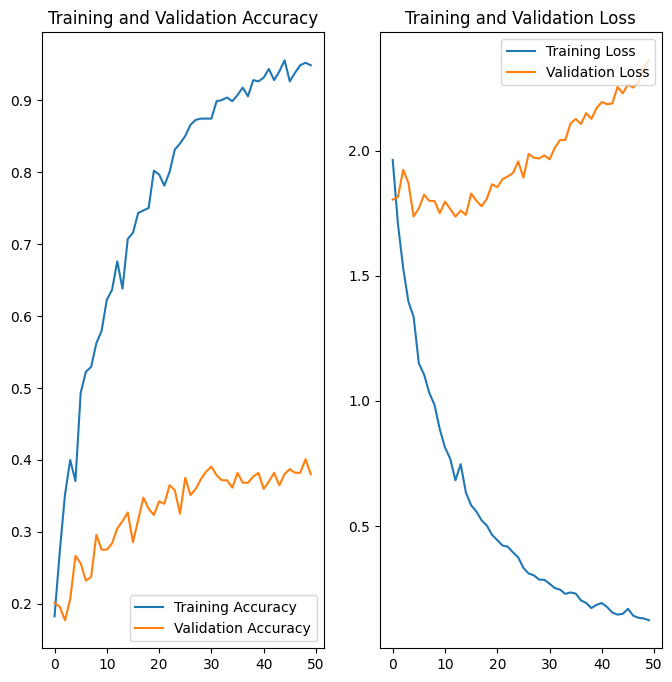

In [397]:
plot_acuracy_loss(history_stg2_sft_cw)

The model performs much worse than the stage 2 softmax baseline initialy, but it's clearly learning, so we can continue tranining to see where it plateaus. 

In [398]:
# Load existing model and continue training
model_stg2_softmax_cw = tf.keras.models.load_model(MODEL_STG2_SFT_CW_PATH)

with open(HISTORY_STG2_SFT_CW_PATH) as f:
    history_stg2_sft_cw = json.load(f)

# Continue training for additional epochs
hist_extra = model_stg2_softmax_cw.fit(
    sft_ds_train2,
    validation_data=sft_ds_val2,
    epochs=20,
    class_weight=class_weight_dict
)

# Stitch histories together
for key in history_stg2_sft_cw:
    history_stg2_sft_cw[key] += hist_extra.history[key]

# Overwrite saved model and history
model_stg2_softmax_cw.save(MODEL_STG2_SFT_CW_PATH)
with open(HISTORY_STG2_SFT_CW_PATH, "w") as f:
    json.dump(history_stg2_sft_cw, f)

print(f"Model saved. Total epochs: {len(history_stg2_sft_cw['accuracy'])}")


Epoch 1/20


I0000 00:00:1775955792.900991   11601 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344197__.49


18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9510 - loss: 0.1058

I0000 00:00:1775955796.022640   11599 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344197__.49


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 446ms/step - accuracy: 0.9552 - loss: 0.1099 - val_accuracy: 0.3907 - val_loss: 2.3478
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.9741 - loss: 0.0993 - val_accuracy: 0.3873 - val_loss: 2.3803
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.9655 - loss: 0.1055 - val_accuracy: 0.3907 - val_loss: 2.3841
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.9621 - loss: 0.0944 - val_accuracy: 0.3907 - val_loss: 2.4123
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.9793 - loss: 0.0895 - val_accuracy: 0.3804 - val_loss: 2.4273
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.9828 - loss: 0.0822 - val_accuracy: 0.3804 - val_loss: 2.4621
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.9672 - loss: 0.0789 - val_accuracy: 0.3890 - val_loss: 2.4730
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.9793 - loss: 0.0810 - val_accuracy: 0.3821 - val

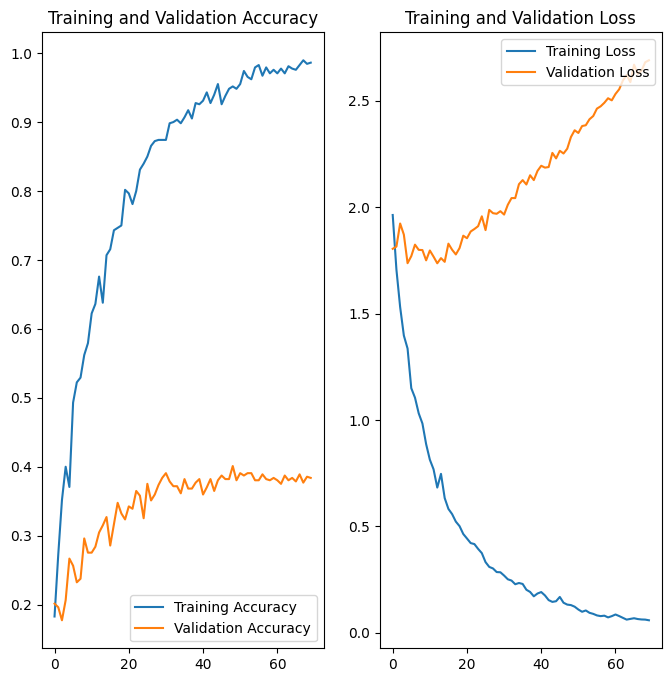

In [399]:
plot_acuracy_loss(history_stg2_sft_cw)

It plateaud at 40%, loss increasing, and the validation accuracy is worse than the stage 2 baseline. It seems to have learned only because it started from a very low point. 

For exploration purposed, I'll keep the class weights as I move on to the next tuning.

#### Retraining with class weights + augmentation

Data augmentation is applied to the training set to artificially increase the effective dataset size and reduce overfitting.

To address class imbalance, rarer buckets are repeated more times before augmentation is applied, effectively oversampling them during training.

Augmentation per bucket

| Bucket | Counts | Original samples | Repeat | Effective samples |
|---|---|---|---|---|
| 0 | 0 | 52 | ×1 | 52 |
| 1 | 1 | 231 | ×1 | 231 |
| 2 | 2 | 106 | ×2 | 212 |
| 3 | 3 | 41 | ×4 | 164 |
| 4 | 4–5 | 17 | ×8 | 136 |
| 5 | 6–9 | 11 | ×12 | 132 |
| 6 | 10+ | 22 | ×10 | 220 |



In [400]:
# ─── Targeted augmentation pipeline ───────────────────────────────────────────
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
], name="augmentation")

# Repeat multiplier per bucket — rarer buckets get repeated more
REPEAT = {0: 1, 1: 1, 2: 2, 3: 4, 4: 8, 5: 12, 6: 10}

# Build per-bucket datasets and concatenate
bucketed_train_labels = np.array([get_bucket(c) for c in train_labels2])

combined_ds = None
for bucket_id, repeat_n in REPEAT.items():
    mask = bucketed_train_labels == bucket_id
    bucket_files  = train_files2[mask]
    bucket_labels = train_labels2[mask]

    if len(bucket_files) == 0:
        continue

    # Build base dataset for this bucket
    ds = tf.data.Dataset.from_tensor_slices((bucket_files, bucket_labels))
    ds = ds.map(lambda p, l: (
        tf.cast(tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(p), channels=3), IMG_SIZE), tf.uint8), l
    ), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(bucket_label)

    if repeat_n > 1:
        ds = ds.repeat(repeat_n).map(normalize_and_augment)
    else:
        ds = ds.map(normalize_only)

    combined_ds = ds if combined_ds is None else combined_ds.concatenate(ds)

sft_aug_targeted_ds_train2 = (
    combined_ds
    .shuffle(buffer_size=10_000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

sft_aug_targeted_ds_val2  = sft_ds_val2
sft_aug_targeted_ds_test2 = sft_ds_test2

# Print effective dataset size per bucket
print("Effective training samples per bucket after oversampling:")
for b, r in REPEAT.items():
    n = (bucketed_train_labels == b).sum()
    print(f"  Bucket {bucket_ranges[b]:>5}: {n} × {r} = {n*r}")


Effective training samples per bucket after oversampling:
  Bucket     0: 152 × 1 = 152
  Bucket     1: 225 × 1 = 225
  Bucket     2: 103 × 2 = 206
  Bucket     3: 40 × 4 = 160
  Bucket   4–5: 23 × 8 = 184
  Bucket   6–9: 11 × 12 = 132
  Bucket   10+: 26 × 10 = 260


In [401]:
MODEL_STG2_SFT_AUG_CW_PATH = "saved_models/model_stg2_softmax_aug_cw.keras"
HISTORY_STG2_SFT_AUG_CW_PATH = "saved_models/model_stg2_softmax_aug_cw_history.json"

if os.path.exists(MODEL_STG2_SFT_AUG_CW_PATH) and os.path.exists(HISTORY_STG2_SFT_AUG_CW_PATH):
    print("Loading saved model_stg2_softmax_aug_cw...")
    model_stg2_softmax_aug_cw = tf.keras.models.load_model(MODEL_STG2_SFT_AUG_CW_PATH)
    with open(HISTORY_STG2_SFT_AUG_CW_PATH) as f:
        history_stg2_sft_aug_cw = json.load(f)
else:
    base = tf.keras.models.load_model("saved_models/model_stg1_v3.keras")
    inp = tf.keras.Input(shape=(128, 128, 3))
    x = inp
    for layer in base.layers:
        x = layer(x)
        layer.trainable = False
        if layer.name == "flatten_2":
            break

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

    model_stg2_softmax_aug_cw = tf.keras.Model(inp, outputs, name="model_stg2_softmax_aug_cw")
    model_stg2_softmax_aug_cw.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    epochs = 30
    hist = model_stg2_softmax_aug_cw.fit(
        sft_aug_targeted_ds_train2,
        validation_data=sft_aug_targeted_ds_val2,
        epochs=epochs,
        class_weight=class_weight_dict
    )
    history_stg2_sft_aug_cw = hist.history
    model_stg2_softmax_aug_cw.save(MODEL_STG2_SFT_AUG_CW_PATH)
    with open(HISTORY_STG2_SFT_AUG_CW_PATH, "w") as f:
        json.dump(history_stg2_sft_aug_cw, f)
    print(f"Model saved to {MODEL_STG2_SFT_AUG_CW_PATH}")



Loading saved model_stg2_softmax_aug_cw...


In [451]:
print(f"Final validation accuracy: {history_stg2_sft_aug['val_accuracy'][-1]:.4f}")


Final validation accuracy: 0.4045


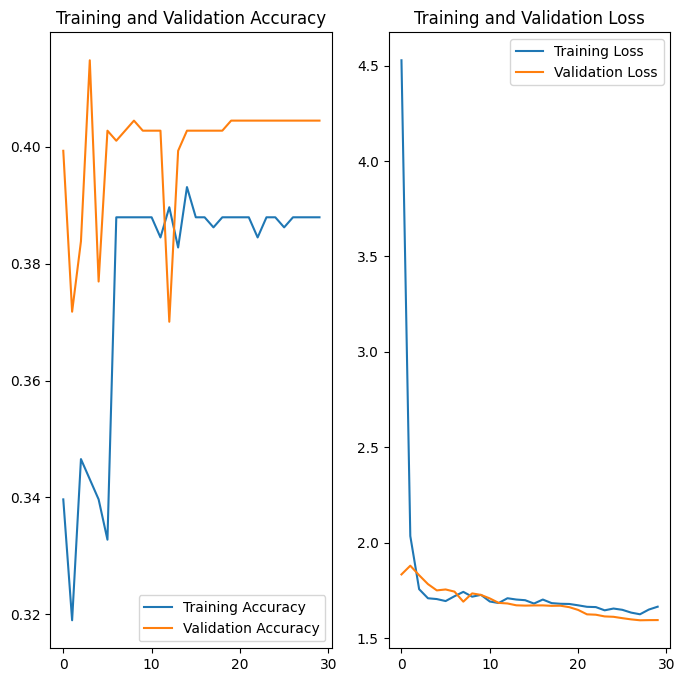

In [402]:
plot_acuracy_loss(history_stg2_sft_aug)

## Modeling - Stage 3 (Turbine Count with Transfer Learning)

Two pre-trained models were selected for transfer learning, both pre-trained on ImageNet:

| Model | Rationale |
|---|---|
| **EfficientNetB0** | Best accuracy-to-parameter ratio; scales well to 128×128; rich spatial features from ImageNet |
| **MobileNetV2** | Extremely lightweight and fast to train; good contrast against EfficientNet |

Each backbone is paired with a new head, giving the following models:

| Model | Model | Task |
|---|---|---|
| `model_tl_effnet_sft` | EfficientNetB0 | Softmax (7 buckets) |
| `model_tl_mobilenet_sft` | MobileNetV2 | Softmax (7 buckets) |

Each architecture requires its own preprocessing function instead of `normalize_image`, as each expects pixel values in a specific range.


### Transfer Learning - MobileNetV2

In [403]:
# ─── MobileNetV2 DS2 Pipeline at 128x128 ──────────────────────────────────────

mobilenet_sft_ds_train2 = (
    train_dataset2
    .map(preprocess_mobilenet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
mobilenet_sft_ds_val2 = (
    val_dataset2
    .map(preprocess_mobilenet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
mobilenet_sft_ds_test2 = (
    test_dataset2
    .map(preprocess_mobilenet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [404]:
mobilenet_base = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3),
    pooling='avg'
)
mobilenet_base.trainable = False

inp = tf.keras.Input(shape=(128, 128, 3))
x = mobilenet_base(inp, training=False)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

model_stg3_mobilenet_sft = tf.keras.Model(inp, outputs, name="model_stg3_mobilenet_sft")
model_stg3_mobilenet_sft.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_stg3_mobilenet_sft.summary()


Model: "model_stg3_mobilenet_sft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_51 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
MODEL_STG3_MOBILENET_SFT_PATH = "saved_models/model_stg3_mobilenet_sft.keras"
HISTORY_STG3_MOBILENET_SFT_PATH = "saved_models/model_stg3_mobilenet_sft_history.json"

if os.path.exists(MODEL_STG3_MOBILENET_SFT_PATH) and os.path.exists(HISTORY_STG3_MOBILENET_SFT_PATH):
    print("Loading saved model_stg3_mobilenet_sft...")
    model_stg3_mobilenet_sft = tf.keras.models.load_model(MODEL_STG3_MOBILENET_SFT_PATH)
    with open(HISTORY_STG3_MOBILENET_SFT_PATH) as f:
        history_stg3_mobilenet_sft = json.load(f)
else:
    epochs = 30
    hist = model_stg3_mobilenet_sft.fit(
        mobilenet_sft_ds_train2,
        validation_data=mobilenet_sft_ds_val2,
        epochs=epochs,
        class_weight=class_weight_dict
    )
    history_stg3_mobilenet_sft = hist.history
    model_stg3_mobilenet_sft.save(MODEL_STG3_MOBILENET_SFT_PATH)
    with open(HISTORY_STG3_MOBILENET_SFT_PATH, "w") as f:
        json.dump(history_stg3_mobilenet_sft, f)
    print(f"Model saved to {MODEL_STG3_MOBILENET_SFT_PATH}")
    

Loading saved model_stg3_mobilenet_sft...


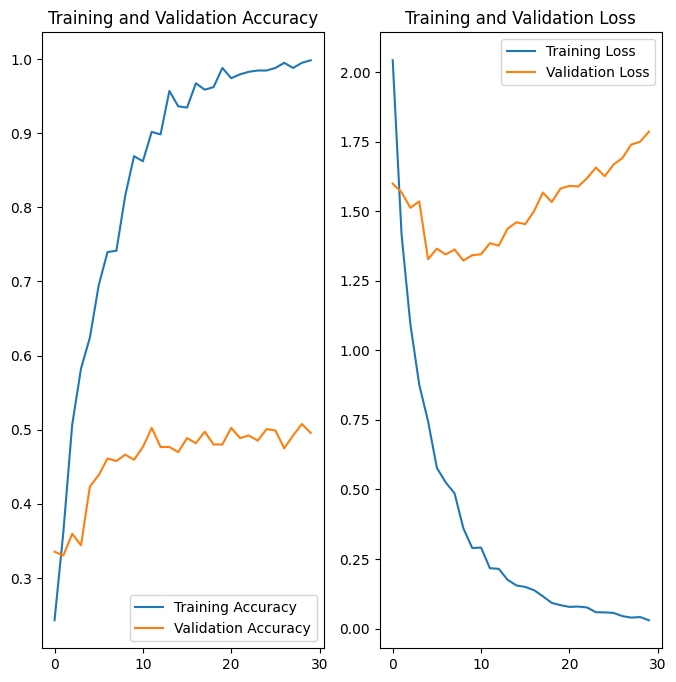

In [406]:
plot_acuracy_loss(history_stg3_mobilenet_sft)


Training hits ~100% while validation plateaus at ~50% and validation loss rises. 

This model perfoms better than the custom architecture already, but it the root cause seems to be the same as before: model is too large for such a small image sample (580).

Since augmentation seemed to work before, let's do it again. This time, we'll also reduce the dense layer size so that the model doesn't memorize the data so quickly and hopefully generalizes better. 

### Transfer Learning MobileNetV2 - Augmentation and reduced dense layer

In [407]:
# ─── MobileNetV2 DS2 Pipeline at 128x128 (augmented) ─────────────────────────
mobilenet_sft_aug_ds_train2 = (
    train_dataset2
    .map(preprocess_mobilenet_aug)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
mobilenet_sft_aug_ds_val2  = mobilenet_sft_ds_val2
mobilenet_sft_aug_ds_test2 = mobilenet_sft_ds_test2


In [408]:
mobilenet_base = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3),
    pooling='avg'
)
mobilenet_base.trainable = False

inp = tf.keras.Input(shape=(128, 128, 3))
x = mobilenet_base(inp, training=False)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

model_stg3_mobilenet_sft_v2 = tf.keras.Model(inp, outputs, name="model_stg3_mobilenet_sft_v2")
model_stg3_mobilenet_sft_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_stg3_mobilenet_sft_v2.summary()


Model: "model_stg3_mobilenet_sft_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_53 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,207 (8.77 MB)

 Trainable params: 41,223 (161.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [409]:
MODEL_STG3_MOBILENET_SFT_V2_PATH = "saved_models/model_stg3_mobilenet_sft_v2.keras"
HISTORY_STG3_MOBILENET_SFT_V2_PATH = "saved_models/model_stg3_mobilenet_sft_v2_history.json"

if os.path.exists(MODEL_STG3_MOBILENET_SFT_V2_PATH) and os.path.exists(HISTORY_STG3_MOBILENET_SFT_V2_PATH):
    print("Loading saved model_stg3_mobilenet_sft_v2...")
    model_stg3_mobilenet_sft_v2 = tf.keras.models.load_model(MODEL_STG3_MOBILENET_SFT_V2_PATH)
    with open(HISTORY_STG3_MOBILENET_SFT_V2_PATH) as f:
        history_stg3_mobilenet_sft_v2 = json.load(f)
else:
    epochs = 30
    hist = model_stg3_mobilenet_sft_v2.fit(
        mobilenet_sft_aug_ds_train2,
        validation_data=mobilenet_sft_aug_ds_val2,
        epochs=epochs,
        class_weight=class_weight_dict
    )
    history_stg3_mobilenet_sft_v2 = hist.history
    model_stg3_mobilenet_sft_v2.save(MODEL_STG3_MOBILENET_SFT_V2_PATH)
    with open(HISTORY_STG3_MOBILENET_SFT_V2_PATH, "w") as f:
        json.dump(history_stg3_mobilenet_sft_v2, f)
    print(f"Model saved to {MODEL_STG3_MOBILENET_SFT_V2_PATH}")



Loading saved model_stg3_mobilenet_sft_v2...


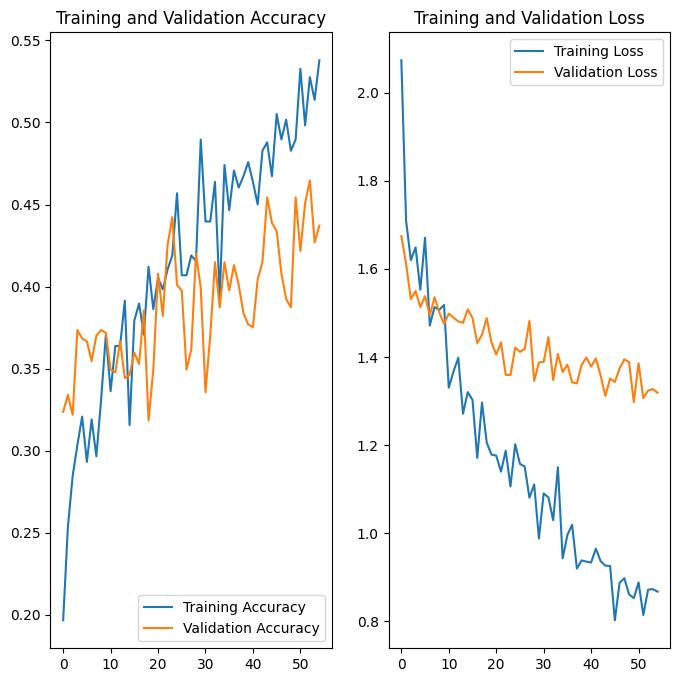

In [410]:
plot_acuracy_loss(history_stg3_mobilenet_sft_v2)

Again overfitting was fixed and the model is learning now. Let's run a few more epochs.

In [411]:
model_stg3_mobilenet_sft_v2 = tf.keras.models.load_model(MODEL_STG3_MOBILENET_SFT_V2_PATH)

hist_extra = model_stg3_mobilenet_sft_v2.fit(
    mobilenet_sft_aug_ds_train2,
    validation_data=mobilenet_sft_aug_ds_val2,
    epochs=25,
    class_weight=class_weight_dict
)

for key in history_stg3_mobilenet_sft_v2:
    history_stg3_mobilenet_sft_v2[key] += hist_extra.history[key]

model_stg3_mobilenet_sft_v2.save(MODEL_STG3_MOBILENET_SFT_V2_PATH)
with open(HISTORY_STG3_MOBILENET_SFT_V2_PATH, "w") as f:
    json.dump(history_stg3_mobilenet_sft_v2, f)

print(f"Total epochs: {len(history_stg3_mobilenet_sft_v2['accuracy'])}")


Epoch 1/25


I0000 00:00:1775955912.464038   11598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_368257__.119


18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5527 - loss: 0.7781

I0000 00:00:1775955922.082643   11601 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_368257__.119


19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5466 - loss: 0.8416 - val_accuracy: 0.4596 - val_loss: 1.2761
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 546ms/step - accuracy: 0.5345 - loss: 0.7959 - val_accuracy: 0.4303 - val_loss: 1.3525
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step - accuracy: 0.5155 - loss: 0.8073 - val_accuracy: 0.4475 - val_loss: 1.3780
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 425ms/step - accuracy: 0.5293 - loss: 0.8104 - val_accuracy: 0.4544 - val_loss: 1.2940
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 322ms/step - accuracy: 0.5672 - loss: 0.8099 - val_accuracy: 0.4372 - val_loss: 1.3567
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.5483 - loss: 0.7541 - val_accuracy: 0.4596 - val_loss: 1.3336
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.5224 - loss: 0.7937 - val_accuracy: 0.4458 - val_loss: 1.3226
Epoch 8/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 412ms/step - accuracy: 0.5241 - loss: 0.8244 - val_accuracy: 0.4630 - val

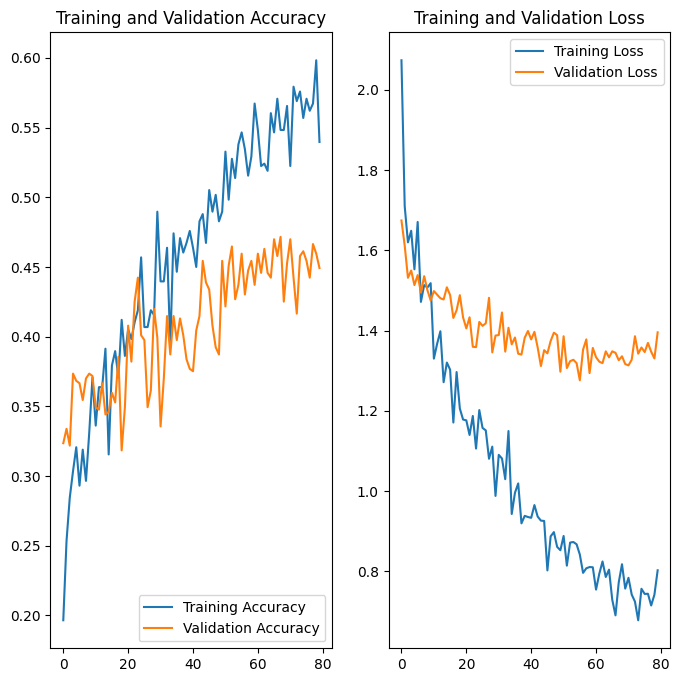

In [412]:
plot_acuracy_loss(history_stg3_mobilenet_sft_v2)


It learned for longer but started to diverge revealing overfitting. Let's move forward to see if we can improve the accuracy through resolution increase.

### Transfer Learning EfficientNetB0 Pipeline (increased resolution)

In [413]:
# ─── DS2 at 224x224 for EfficientNetB0 ───────────────────────────────────────
IMG_SIZE_224 = (224, 224)

train_dataset2_224 = make_dataset_224(train_files2, train_labels2, shuffle=True)
test_dataset2_224  = make_dataset_224(test_files2,  test_labels2)
val_dataset2_224   = make_dataset_224(val_files2,   val_labels2)

print(f"Train: {len(train_files2)} | Test: {len(test_files2)} | Val: {len(val_files2)}")


Train: 580 | Test: 581 | Val: 581


In [414]:
# ─── EfficientNet DS2 Pipelines at 224x224 ────────────────────────────────────

BATCH_SIZE = 32

eff_sft_ds_train2 = (
    train_dataset2_224
    .map(preprocess_effnet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
eff_sft_ds_val2 = (
    val_dataset2_224
    .map(preprocess_effnet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
eff_sft_ds_test2 = (
    test_dataset2_224
    .map(preprocess_effnet)
    .map(bucket_label)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [415]:
# ─── EfficientNetB0 Model ─────────────────────────────────────────────────────
effnet_base = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(224, 224, 3), pooling='avg')
effnet_base.trainable = False

inp = tf.keras.Input(shape=(224, 224, 3))
x = effnet_base(inp, training=False)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class_output')(x)

model_stg3_effnet_sft = tf.keras.Model(inp, outputs, name="model_stg3_effnet_sft")
model_stg3_effnet_sft.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_stg3_effnet_sft.summary()



Model: "model_stg3_effnet_sft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_55 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,090,794 (15.61 MB)

 Trainable params: 41,223 (161.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [418]:
MODEL_STG3_EFFNET_SFT_PATH = "saved_models/model_stg3_effnet_sft.keras"

if os.path.exists(MODEL_STG3_EFFNET_SFT_PATH):
    print("Loading saved model_stg3_effnet_sft...")
    model_stg3_effnet_sft = tf.keras.models.load_model(MODEL_STG3_EFFNET_SFT_PATH)
    history_stg3_effnet_sft = None
else:
    epochs = 30
    history_stg3_effnet_sft = model_stg3_effnet_sft.fit(
        eff_sft_ds_train2,
        validation_data=eff_sft_ds_val2,
        epochs=epochs
    )
    model_stg3_effnet_sft.save(MODEL_STG3_EFFNET_SFT_PATH)
    print(f"Model saved to {MODEL_STG3_EFFNET_SFT_PATH}")


Epoch 1/30


I0000 00:00:1775956460.617222   11601 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_394594__.251


18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6979 - loss: 1.0763

I0000 00:00:1775956483.041483   11601 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_394594__.251
E0000 00:00:1775956486.832395   11601 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775956487.931533   11601 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775956489.788492   11601 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6724 - loss: 1.1181 - val_accuracy: 0.7108 - val_loss: 0.8582
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.7414 - loss: 0.6943 - val_accuracy: 0.7418 - val_loss: 0.7808
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - accuracy: 0.8155 - loss: 0.5188 - val_accuracy: 0.7281 - val_loss: 0.7969
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 301ms/step - accuracy: 0.8672 - loss: 0.3950 - val_accuracy: 0.7367 - val_loss: 0.7975
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 360ms/step - accuracy: 0.8983 - loss: 0.3193 - val_accuracy: 0.7263 - val_loss: 0.8325
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 324ms/step - accuracy: 0.9069 - loss: 0.2808 - val_accuracy: 0.7573 - val_loss: 0.8295
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step - accuracy: 0.9310 - loss: 0.2371 - val_accuracy: 0.7315 - val_loss: 0.8301
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.9500 - loss: 0.1983 - val_accuracy: 0.7573 - val_lo

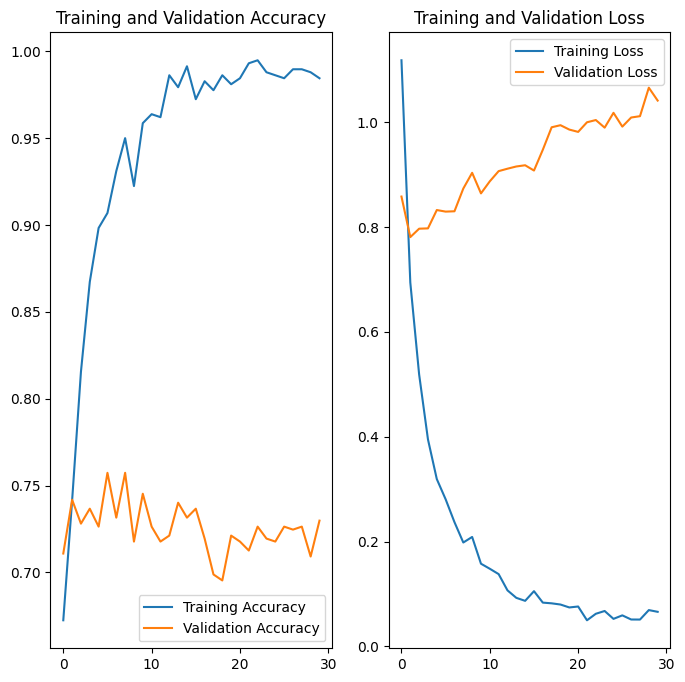

In [419]:
plot_acuracy_loss(history_stg3_effnet_sft)


~72% on 7 buckets with ~580 training images is surprising and better than a dummy classifier that would bet on class 1 all the time (40% accuracy) — the model has very few samples on the tail buckets (4-5, 6-9, 10+). Not enough signal to learn the boundaries between classes.

This model with better image resolution instantly quickly performed better than previous models after a couple of epochs, but then overfit and plateaud - sample size very small.

Let's now apply all the techniques that worked before to fix regularization and improve learning with augmentation:
- Regularization
- Dropout
- Class targetted augmentation + class weights

In [ ]:
# ─── EfficientNetB0 Augmented Pipeline at 224×224 ─────────────────────────────
augment_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
], name="augmentation")

bucketed_train_labels_eff = np.array([get_bucket_np(l) for l in train_labels2])

REPEAT_EFF = {0: 1, 1: 1, 2: 2, 3: 4, 4: 8, 5: 12, 6: 10}

combined_eff_aug = None
for bucket_id, repeat_n in REPEAT_EFF.items():
    mask = bucketed_train_labels_eff == bucket_id
    ds = tf.data.Dataset.from_tensor_slices((train_files2[mask], train_labels2[mask]))
    ds = ds.map(load_and_resize_224,  num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(bucket_label,         num_parallel_calls=tf.data.AUTOTUNE)
    if repeat_n > 1:
        ds = ds.repeat(repeat_n).map(effnet_augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(effnet_only, num_parallel_calls=tf.data.AUTOTUNE)
    combined_eff_aug = ds if combined_eff_aug is None else combined_eff_aug.concatenate(ds)

eff_aug_sft_ds_train2 = (combined_eff_aug
    .shuffle(buffer_size=5000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

eff_aug_sft_ds_val2 = (val_dataset2_224
    .map(effnet_only,   num_parallel_calls=tf.data.AUTOTUNE)
    .map(bucket_label,  num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

eff_aug_sft_ds_test2 = (test_dataset2_224
    .map(effnet_only,   num_parallel_calls=tf.data.AUTOTUNE)
    .map(bucket_label,  num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))


In [ ]:
# ─── EfficientNetB0 v2 — Regularisation + Dropout ────────────────────────────
effnet_base = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(224, 224, 3), pooling='avg')
effnet_base.trainable = False

inp = tf.keras.Input(shape=(224, 224, 3))
x = effnet_base(inp, training=False)
x = tf.keras.layers.Dense(64, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax',
                                 name='class_output')(x)

model_stg3_effnet_sft_v2 = tf.keras.Model(inp, outputs,
                                            name="model_stg3_effnet_sft_v2")
model_stg3_effnet_sft_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_stg3_effnet_sft_v2.summary()


Model: "model_stg3_effnet_sft_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_41 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,132,010 (15.76 MB)

 Trainable params: 82,439 (322.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ─── Training: model_stg3_effnet_sft_v2 ──────────────────────────────────────
MODEL_PATH    = "saved_models/model_stg3_effnet_sft_v2.keras"
HISTORY_PATH  = "saved_models/model_stg3_effnet_sft_v2_history.json"

# Class weights on the oversampled train labels
all_bucketed = np.array([get_bucket_np(l) for l in train_labels2])
cw_values = compute_class_weight('balanced',
                                  classes=np.arange(NUM_CLASSES),
                                  y=all_bucketed)
class_weight_dict = dict(enumerate(cw_values))
print("Class weights:", {k: f"{v:.2f}" for k, v in class_weight_dict.items()})

if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH):
    model_stg3_effnet_sft_v2 = tf.keras.models.load_model(MODEL_PATH)
    with open(HISTORY_PATH) as f:
        history_stg3_effnet_v2 = json.load(f)
    print("Loaded from disk.")
else:
    hist = model_stg3_effnet_sft_v2.fit(
        eff_aug_sft_ds_train2,
        validation_data=eff_aug_sft_ds_val2,
        epochs=50,
        class_weight=class_weight_dict
    )
    history_stg3_effnet_v2 = hist.history
    model_stg3_effnet_sft_v2.save(MODEL_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history_stg3_effnet_v2, f)
    print("Training complete and saved.")


Class weights: {0: '0.55', 1: '0.37', 2: '0.80', 3: '2.07', 4: '3.60', 5: '7.53', 6: '3.19'}
Loaded from disk.


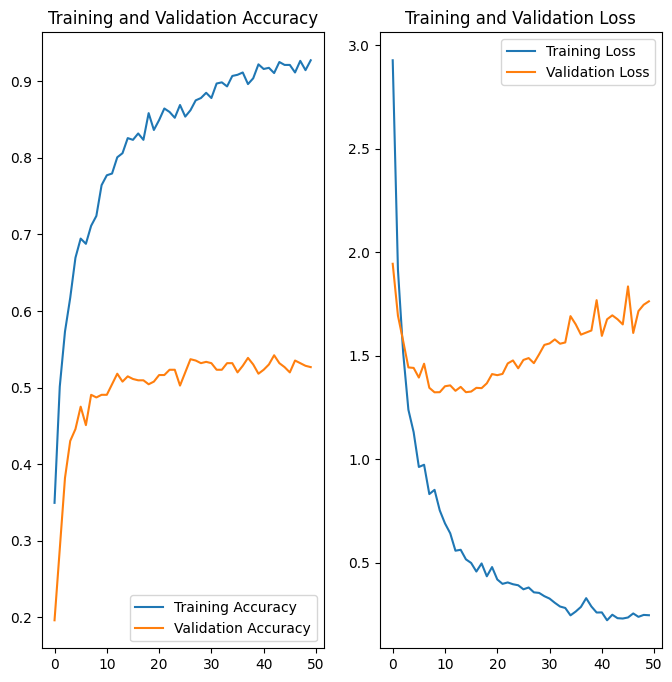

In [ ]:
plot_acuracy_loss(history_stg3_effnet_v2)


The model was not learning but performed better before. The techniques that worked on reducing overfitting in previous trials, seem to have made the model perform worse this time. This hints that:

- The regularization might have been too aggressive.
- Applying all the techniques at once made the model worse at learning signal.

We could keep trying to fine tune but given the conclusions so far and the dataset size I'll move on.

At this point it is important to notice that accuracy is a BAD metric to evaluate the performance of a model when the dataset is so imbalanced. 

Other metrics such as Cohen's Kappa (https://scikit-learn.org/stable/modules/model_evaluation.html#cohen-kappa) are better suited for problems like this.
- Measures agreement beyond chance — penalises a model that just predicts the majority class.
- It is ordinal aware, penalising predictions that are far off (ordinal-aware — important for counts).

Although it's outside of the scope, let's calculate it out of curiosity just to see how the model places generaly speaking.

In [ ]:
# Load if not in memory
MODEL_STG2_PATH = "saved_models/model_stg2_softmax.keras"
if 'model_stg2_softmax' not in dir():
    model_stg2_softmax = tf.keras.models.load_model(MODEL_STG2_PATH)

y_pred_probs_stg2 = model_stg2_softmax.predict(sft_ds_val2)
y_pred_stg2 = np.argmax(y_pred_probs_stg2, axis=1)
y_true_stg2 = np.concatenate([y.numpy() for _, y in sft_ds_val2])

qwk_stg2      = cohen_kappa_score(y_true_stg2, y_pred_stg2, weights='quadratic')
macro_f1_stg2 = f1_score(y_true_stg2, y_pred_stg2, average='macro')
acc_stg2      = (y_pred_stg2 == y_true_stg2).mean()

print("── Stage 2 (model_stg2_softmax) ──────────────────")
print(f"Accuracy:                 {acc_stg2:.4f}")
print(f"Macro F1:                 {macro_f1_stg2:.4f}")
print(f"Quadratic Weighted Kappa: {qwk_stg2:.4f}")

print("\n── Stage 3 (model_stg3_effnet_sft_v2) ───────────")
print(f"Accuracy:                 {acc:.4f}")
print(f"Macro F1:                 {macro_f1:.4f}")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
── Stage 2 (model_stg2_softmax) ──────────────────
Accuracy:                 0.4716
Macro F1:                 0.3036
Quadratic Weighted Kappa: 0.2059

── Stage 3 (model_stg3_effnet_sft_v2) ───────────
Accuracy:                 0.5267
Macro F1:                 0.3637
Quadratic Weighted Kappa: 0.6263


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


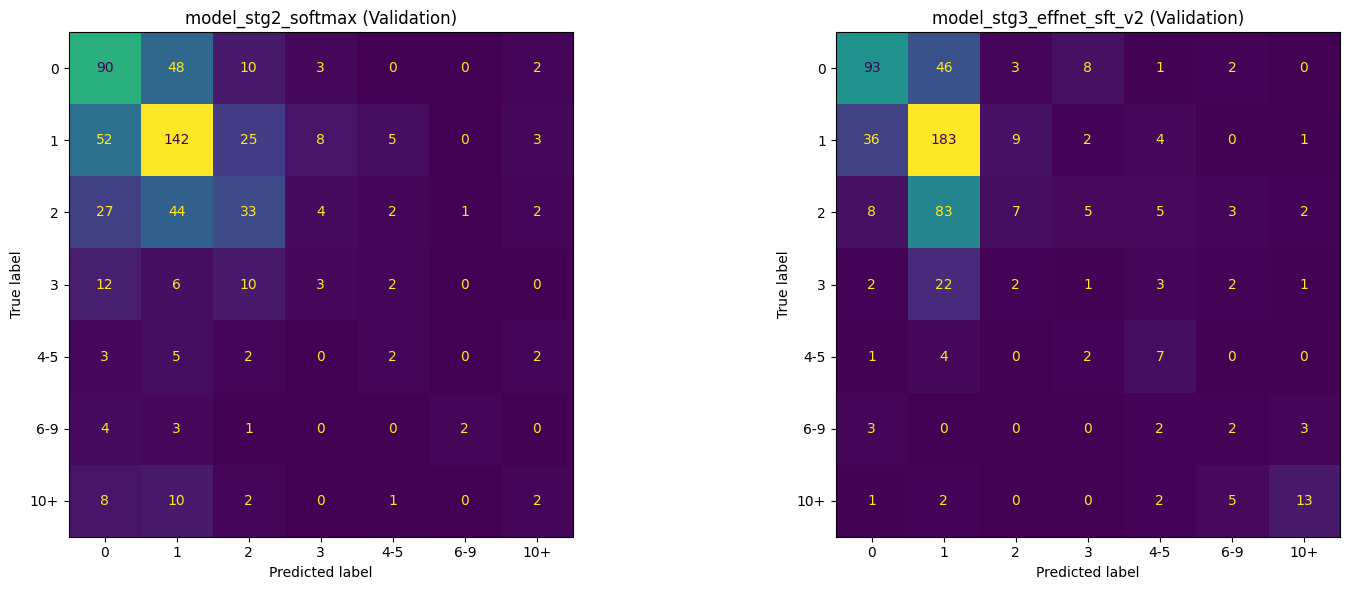

In [ ]:
# Stage 2 predictions
y_pred_probs_stg2 = model_stg2_softmax.predict(sft_ds_val2)
y_pred_stg2 = np.argmax(y_pred_probs_stg2, axis=1)
y_true_stg2 = np.concatenate([y.numpy() for _, y in sft_ds_val2])

cm_stg2 = confusion_matrix(y_true_stg2, y_pred_stg2, labels=list(range(NUM_CLASSES)))
cm_stg3 = confusion_matrix(y_true,      y_pred,      labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm_stg2, display_labels=BUCKET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("model_stg2_softmax (Validation)")

ConfusionMatrixDisplay(cm_stg3, display_labels=BUCKET_LABELS).plot(ax=axes[1], colorbar=False)
axes[1].set_title("model_stg3_effnet_sft_v2 (Validation)")

plt.tight_layout()
plt.show()


#### Conclusions for this stage

A 0.62 Cohen's Kappa suggests the model and the ground truth agree substantially more than a random guesser would, accounting for the fact that some agreement would happen by chance alone even with random predictions. Generally, this is the interpretation for Cohen's Kappa:

| Range | Interpretation |
|-------|----------------|
| < 0 | Worse than random |
| 0.0 – 0.2 | Slight |
| 0.2 – 0.4 | Fair |
| 0.4 – 0.6 | Moderate |
| 0.6 – 0.8 | Substantial |
| 0.8 – 1.0 | Almost perfect |

When we look at accuracy, the baseline model model_stg2_softmax had an accuracy of 47%, while model_stg3_effnet_sft_v2 had a score of 53%, only 5-6% better. But when we look at Cohen's Kappa, we can see that the baseline model had a Cohen's Kappa of 0.2 (being at the frontier between slight/fair agreement), meaning that it was ignoring the ordinal dimension and classifying images with a high number of images as having none or few. It was basically betting on the most common classes almost all the time.

This can be confirmed by looking at the confusion matrix of both models side by side.

Having exhausted techniques to try to improve turbine counting, several conclusions became apparent:
- Regularization, Augmentation, Dropout help reducing overfitting as expected, across different models.
- Certain techniques like augmentation and class weights showed an improvement in the learning process independently from overfitting.
- But overall it was difficult to go above a certain threshold ~55%.
- The parameter that improved the performance the most was image resolution - which was expected but has a computational cost.

There are other techniques that could be used that will be discussed in the future work section.

## Modeling - Stage 4 (Return to binary classification)

At this point, out of curiosity, let's try framing the problem as binary classification again to see the accuracy of the model created in **Wind Turbine Detection**. Since we already know the sample is too small, let's run with augmentation from the get-go to address class imbalance and L2 regularization and Dropout to address overfitting.

In [428]:
# ─── EfficientNet Binary Pipeline at 224×224 ─────────────────────────────────
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
], name="augmentation")

BATCH_SIZE = 32

eff_bin_ds_train2_aug = (
    train_dataset2_224
    .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .map(make_binary_label,      num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eff_bin_ds_val2 = (
    val_dataset2_224
    .map(effnet_only,        num_parallel_calls=tf.data.AUTOTUNE)
    .map(make_binary_label,  num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eff_bin_ds_test2 = (
    test_dataset2_224
    .map(effnet_only,        num_parallel_calls=tf.data.AUTOTUNE)
    .map(make_binary_label,  num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [425]:
# ─── model_stg4_effnet_binary_aug ────────────────────────────────────────────
effnet_base_bin_aug = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'
)
effnet_base_bin_aug.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = effnet_base_bin_aug(inputs, training=False)
x = tf.keras.layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, name='binary_output')(x)

model_stg4_effnet_binary_aug = tf.keras.Model(inputs, outputs,
                                               name="model_stg4_effnet_binary_aug")
model_stg4_effnet_binary_aug.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model_stg4_effnet_binary_aug.summary()



Model: "model_stg4_effnet_binary_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_60 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [429]:
# ─── Training: model_stg4_effnet_binary_aug ───────────────────────────────────
MODEL_PATH   = "saved_models/model_stg4_effnet_binary_aug.keras"
HISTORY_PATH = "saved_models/model_stg4_effnet_binary_aug_history.json"

if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH):
    print("Loading saved model_stg4_effnet_binary_aug...")
    model_stg4_effnet_binary_aug = tf.keras.models.load_model(MODEL_PATH)
    with open(HISTORY_PATH) as f:
        history_stg4_effnet_bin_aug = json.load(f)
else:
    hist = model_stg4_effnet_binary_aug.fit(
        eff_bin_ds_train2_aug,
        validation_data=eff_bin_ds_val2,
        epochs=30
    )
    history_stg4_effnet_bin_aug = hist.history
    model_stg4_effnet_binary_aug.save(MODEL_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history_stg4_effnet_bin_aug, f)
    print(f"Model saved to {MODEL_PATH}")


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7828 - loss: 0.4479 - val_accuracy: 0.8021 - val_loss: 0.4676
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 587ms/step - accuracy: 0.7931 - loss: 0.4084 - val_accuracy: 0.8072 - val_loss: 0.4519
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 789ms/step - accuracy: 0.7845 - loss: 0.3984 - val_accuracy: 0.8176 - val_loss: 0.4352
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 630ms/step - accuracy: 0.8379 - loss: 0.3700 - val_accuracy: 0.8124 - val_loss: 0.4413
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 531ms/step - accuracy: 0.8397 - loss: 0.3617 - val_accuracy: 0.8107 - val_loss: 0.4490
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 594ms/step - accuracy: 0.8466 - loss: 0.3520 - val_accuracy: 0.8176 - val_loss: 0.4316
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 471ms/step - accuracy: 0.8655 - loss: 0.3311 - val_accuracy: 0.8210 - val_loss: 0.4528
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 483ms/step - accuracy: 0.8586 - loss: 0.3238 - val_accuracy:

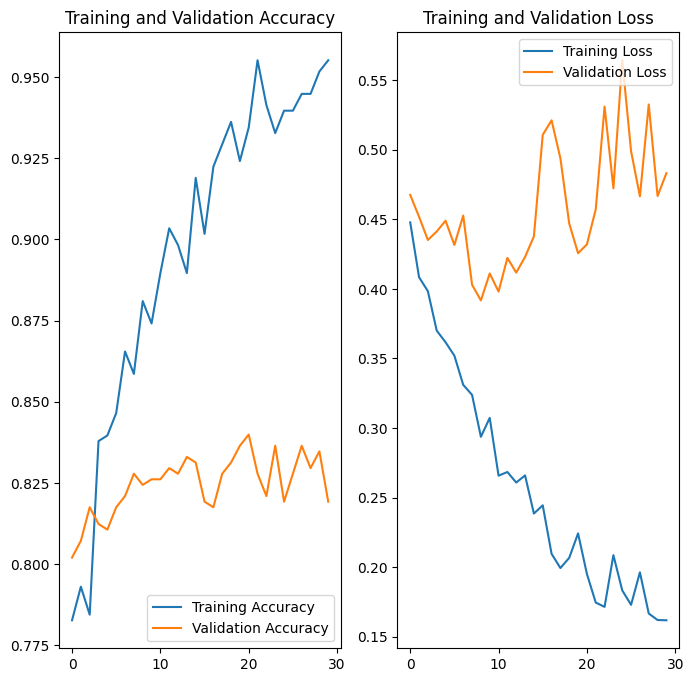

In [430]:
if history_stg4_effnet_bin_aug is not None:
    plot_acuracy_loss(history_stg4_effnet_bin_aug)
else:
    print("Model was loaded from disk — no training history available.")

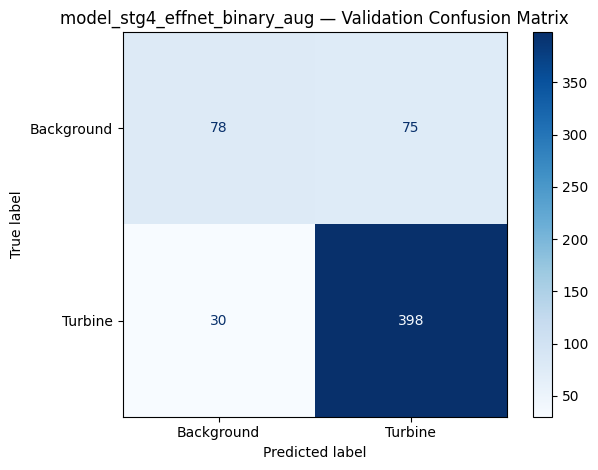

Overall accuracy: 0.8193


In [431]:
# Collect ground truth and predictions from validation set
y_true, y_pred = [], []

for images, labels in eff_bin_ds_val2:
    logits = model_stg4_effnet_binary_aug.predict(images, verbose=0)
    probs = tf.sigmoid(logits).numpy().flatten()
    preds = (probs >= 0.5).astype(int)
    y_true.extend(labels.numpy().flatten().astype(int))
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background", "Turbine"])
disp.plot(cmap="Blues")
plt.title("model_stg4_effnet_binary_aug — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"Overall accuracy: {(y_true == y_pred).mean():.4f}")


# Predict for the test set

In [452]:
# ── Final Test Set Evaluation — Stage 1 ──────────────────────────────────────
sub_ds_test1_batched = sub_ds_test1.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

stg1_results = []

for name, path in [
    ("model_stg1_baseline", "saved_models/model_stg1_baseline.keras"),
    ("model_stg1_v2",       "saved_models/model_stg1_v2.keras"),
    ("model_stg1_v3",       "saved_models/model_stg1_v3.keras"),
]:
    m = tf.keras.models.load_model(path)
    acc, _ = evaluate_binary(m, sub_ds_test1_batched)
    stg1_results.append((name, f"{acc:.4f}", "—"))

print(f"{'Model':<35} {'Test Accuracy':>14} {'QWK':>8}")
print("─" * 60)
for name, acc, qwk in stg1_results:
    print(f"{name:<35} {acc:>14} {qwk:>8}")


Model                                Test Accuracy      QWK
────────────────────────────────────────────────────────────
model_stg1_baseline                         0.9300        —
model_stg1_v2                               0.6850        —
model_stg1_v3                               0.9300        —


In [ ]:
# ─── Final Test Set Evaluation — Stage 2, 3, 4 ───────────────────────────────────
from sklearn.metrics import cohen_kappa_score, f1_score

eff_sft_ds_test2_224 = (
    test_dataset2_224
    .map(effnet_only,  num_parallel_calls=tf.data.AUTOTUNE)
    .map(bucket_label, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

bin_ds_test2 = (
    test_dataset2
    .map(normalize_image,    num_parallel_calls=tf.data.AUTOTUNE)
    .map(make_binary_label,  num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

results = []

# ── Stage 2 ───────────────────────────────────────────────────────────────────
for name, path in [
    ("model_stg2_softmax",        "saved_models/model_stg2_softmax.keras"),
    ("model_stg2_softmax_cw",     "saved_models/model_stg2_softmax_cw.keras"),
    ("model_stg2_softmax_aug",    "saved_models/model_stg2_softmax_aug.keras"),
    ("model_stg2_softmax_aug_cw", "saved_models/model_stg2_softmax_aug_cw.keras"),
]:
    m = tf.keras.models.load_model(path)
    acc, qwk = evaluate_softmax(m, sft_ds_test2)
    results.append((name, f"{acc:.4f}", f"{qwk:.4f}"))

# ── Stage 3 ───────────────────────────────────────────────────────────────────
for name, path in [
    ("model_stg3_mobilenet_sft",    "saved_models/model_stg3_mobilenet_sft.keras"),
    ("model_stg3_mobilenet_sft_v2", "saved_models/model_stg3_mobilenet_sft_v2.keras"),
]:
    m = tf.keras.models.load_model(path)
    acc, qwk = evaluate_softmax(m, sft_ds_test2)
    results.append((name, f"{acc:.4f}", f"{qwk:.4f}"))

for name, path, ds in [
    ("model_stg3_effnet_sft",     "saved_models/model_stg3_effnet_sft.keras",     eff_sft_ds_test2_224),
    ("model_stg3_effnet_sft_v2",  "saved_models/model_stg3_effnet_sft_v2.keras",  eff_sft_ds_test2_224),
]:
    m = tf.keras.models.load_model(path)
    acc, qwk = evaluate_softmax(m, ds)
    results.append((name, f"{acc:.4f}", f"{qwk:.4f}"))

# ── Stage 4 ───────────────────────────────────────────────────────────────────
for name, path, ds in [
    ("model_stg4_effnet_binary_aug", "saved_models/model_stg4_effnet_binary_aug.keras", eff_bin_ds_test2),
]:
    m = tf.keras.models.load_model(path)
    acc, _ = evaluate_binary(m, ds)
    results.append((name, f"{acc:.4f}", "—"))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Model':<35} {'Test Accuracy':>14} {'QWK':>8}")
print("─" * 60)
for name, acc, qwk in results:
    print(f"{name:<35} {acc:>14} {qwk:>8}")



Model                                Test Accuracy      QWK
────────────────────────────────────────────────────────────
model_stg2_softmax                          0.5146   0.3011
model_stg2_softmax_cw                       0.4010   0.2534
model_stg2_softmax_aug                      0.4010   0.0000
model_stg2_softmax_aug_cw                   0.3873   0.0365
model_stg3_mobilenet_sft                    0.3907   0.4054
model_stg3_mobilenet_sft_v2                 0.3632   0.4144
model_stg3_effnet_sft                       0.6747   0.7773
model_stg3_effnet_sft_v2                    0.5077   0.5384
model_stg4_effnet_binary_aug                0.8279        —


# The utility of the model (s) created

| Model | Description | Stage | Purpose | Techniques Applied | Val Accuracy | Test Accuracy | QWK (Test) |
|---|---|---|---|---|---|---|---|
| model_stg1_baseline | Custom CNN | 1 — DS1 | Turbine detection | Custom CNN, 128×128 | ~95% | 93.00% | — |
| model_stg1_v2 | Custom CNN | 1 — DS1 | Turbine detection | - | ~98.4% | 68.50% | — |
| model_stg1_v3 | Custom CNN | 1 — DS1 | Turbine detection | Dropout, regularisation | ~98.6% | 93.00% | — |
| model_stg2_softmax | Custom CNN | 2 — DS2 | Count (7 buckets) | Custom CNN, bucketed softmax | 47.16% | 51.46% | 0.31 |
| model_stg2_softmax_cw | Custom CNN | 2 — DS2 | Count (7 buckets) | + Class weights | 38.38% | 40.10% | 0.25 |
| model_stg2_softmax_aug_cw | Custom CNN | 2 — DS2 | Count (7 buckets) | + Augmentation + class weights | 40.45% | 38.73% | 0.04 |
| model_stg3_mobilenet_sft | MobileNetV2 transfer | 3 — DS2 | Count (7 buckets) | MobileNetV2 frozen, 128×128 | 44.92% | 39.07% | 0.41 |
| model_stg3_mobilenet_sft_v2 | MobileNetV2 transfer | 3 — DS2 | Count (7 buckets) | + Smaller head, augmentation | 44.92% | 36.32% | 0.41 |
| model_stg3_effnet_sft | EfficientNetB0 transfer | 3 — DS2 | Count (7 buckets) | EfficientNetB0 frozen, 224×224 | 72.98%* | 67.47% | 0.78 |
| model_stg3_effnet_sft_v2 | EfficientNetB0 transfer | 3 — DS2 | Count (7 buckets) | + L2 reg, dropout, class weights, augmentation | 52.67% | 50.77% | 0.54 |
| model_stg4_effnet_binary_aug | EfficientNetB0 transfer | 4 — DS2 | Turbine detection | EfficientNetB0 frozen + Augmentation | 87.61% | 82.79% | — |




### Objective completion
- The objective was partially met, as the first objective to Perform Binary Classification, detecting if images **contain** or do **not contain** wind turbines was achieved very close to target.
- As for the second objective, it wasn't met. There was a glimpse of a useful model for *Turbine Counting*, but nothing close to the desired accuracy. 

### Observations on the models
**Stage 1**

The baseline model _model_stg1_baseline_ performed well in training, reaching the target accuracy, but was missing 2% to reach the target in testing - the test subset (200 samples) is smaller than the validation set (500), which could explain the underperformance. 

Overfitting was achieved with V2, and one interesting conclusion is that even though the Val accuracy (~98.4%) was close the training accuracy (~99.5%), the overfitting was visible and, alas: the model only scored 68.5% when presented the test set, meaning is generalized badly.

With V3, overfitting was fixed and the test accuracy improved again, but couldn't perform better than the baseline in the test set.

**Stage 2 - Custom CNN**

The custom CNN trained for Turbine Detection did not transfer well to the second dataset. I expected a great challenge because the images were not the same resolution, not the same zoom/cropping, but I didn't expect such poor performance. I would like to have had the time to explore why this happened - I believe trying to transfer from a binary label to a multiclass label could be one of the root causes leading the model to predict mostly 0 or 1, even if we tried to train the head with the new dataset. 

The model performed close to a dummy model that would predict the same category all the time - seen in the accuracy and confirmed with Quadratic Weighted Kappa (agreement). This renders all versions of the custom CNN useless.

**Stage 3 - MobileNetV2**

This model, performed badly, displaying a similar accuracy to the Custom CNN, but in this instance we can see by observing the Quadratic Weighted Kappa that this model behaves better by at least trying to account for ordinality and not predicting 1 all the time.

**Stage 3/4 - EfficientNetB0**

This was the best model, and although it did not achieve the desired target of 95%, it is a useful model, as it is better than a dummy model in terms of accuracy, and scores well on Quadratic Weighted Kappa which measures the agreement between predictions and true labels, beyond chance, penalising large misses more than small ones (basically showing that the model accounts for ordinality and when it misses it's not by a lot). In fact, it scores at the top of substantial agreement in the scale.


# Future work

**Personal comment** 

This assignment was a great learning on many aspects: both about technical details, but mostly about methodology and how it can be tricky to gauge the amount of work.

One of the learnings was that I dismissed the depth of the first dataset when I got 95% accuracy with such a simple model. 
By doing so, I have effectivelly overcomplicated by adding a second stage with a second dataset (knowing it was not a great dataset), when in hindsight there was so much to explore and optimize by working with the first dataset. 
Even if I were to add the second dataset, I could've done so only for binary classification, there was no need to explore multiclass - I still learned in the process but explored less than I wanted.
I would've liked to explore much more, increase my understanding of the models, explore what features they are extracting from the images and so on. 
I jumped to conclusions too quickly trying to put together a storyline for the assignment and committed to the storyline too early.

**Different approaches to same problem - Dataset 2**

I would still like to improve in the turbine count problem (possibly need more data). There's certainly other approaches to be tested :
- Adapting the input layers or unfreezing the top layers from the pre-trained models, so that they can adapt to ingest satellite images. I used ImageNet and these images are very different from satellite images.
- Train with larger resolution available. Possibly combine this with cropping the images into smaller ones, predict per tile and sum the number of turbines detected per image.
- Mix images from the first dataset, play with different zooms (a sort of augmentation).
- Do what the original labels were built for - predicting the bounding box of the turbines and then count the number of boxes in each image.


**Different problem framing**
- Tackling the count problem with regression instead of bucketted multiclass


**Looking further into the future**
- I'd like to be able to estimate the turbine sizes
- I'd like to try the same for solar panels (and estimate the pannel area).